### 저희는 서브미션 앙상블을 이용하여, 3가지의 모델을 사용하며 각 모델마다의 전처리 및 모델링을 실시하였습니다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#ignore warningss
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [3]:
df_trn = pd.read_csv('train.csv').copy()
df_tst = pd.read_csv('test.csv').copy()
df_sub = pd.read_csv('submission_example.csv').copy()

In [4]:
df_trn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31647 entries, 0 to 31646
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         31647 non-null  object
 1   age        31647 non-null  int64 
 2   job        31647 non-null  object
 3   marital    31647 non-null  object
 4   education  31647 non-null  object
 5   default    31647 non-null  object
 6   balance    31647 non-null  int64 
 7   housing    31647 non-null  object
 8   loan       31647 non-null  object
 9   contact    31647 non-null  object
 10  day        31647 non-null  int64 
 11  month      31647 non-null  object
 12  duration   31647 non-null  int64 
 13  campaign   31647 non-null  int64 
 14  pdays      31647 non-null  int64 
 15  previous   31647 non-null  int64 
 16  poutcome   31647 non-null  object
 17  label      31647 non-null  int64 
dtypes: int64(8), object(10)
memory usage: 4.3+ MB


In [5]:
df_tst.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13564 entries, 0 to 13563
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         13564 non-null  object 
 1   age        13564 non-null  int64  
 2   job        13564 non-null  object 
 3   marital    13564 non-null  object 
 4   education  13564 non-null  object 
 5   default    13564 non-null  object 
 6   balance    13564 non-null  int64  
 7   housing    13564 non-null  object 
 8   loan       13564 non-null  object 
 9   contact    13564 non-null  object 
 10  day        13564 non-null  int64  
 11  month      13564 non-null  object 
 12  duration   13564 non-null  int64  
 13  campaign   13564 non-null  int64  
 14  pdays      13564 non-null  int64  
 15  previous   13564 non-null  int64  
 16  poutcome   13564 non-null  object 
 17  label      0 non-null      float64
dtypes: float64(1), int64(7), object(10)
memory usage: 1.9+ MB


* 'ID' 변수 삭제

In [6]:
df_trn.drop(columns=['ID'], inplace=True)

-----------------------------------------

# **XGBoost**

-----------------------------------------

# Feature Engineering

In [7]:
df_trn['No_Depts'] = ((df_trn['default'] == 'no') & (df_trn['loan'] == 'no') & (df_trn['housing'] == 'no')).astype(int) 
df_tst['No_Depts'] = ((df_tst['default'] == 'no') & (df_tst['loan'] == 'no') & (df_tst['housing'] == 'no')).astype(int)

In [8]:
df_trn['housingYes'] = ((df_trn['housing'] =='yes') & (df_trn['age'] >= 30) & (df_trn['age'] < 60)).astype(int)
df_tst['housingYes'] = ((df_tst['housing'] =='yes') & (df_tst['age'] >= 30) & (df_tst['age'] < 60)).astype(int)

In [9]:
df_trn['housingNo'] = ((df_trn['housing'] == 'no') & ((df_trn['age'] < 30) | (df_trn['age'] >= 60))).astype(int)
df_tst['housingNo'] = ((df_tst['housing'] == 'no') & ((df_tst['age'] < 30) | (df_tst['age'] >= 60))).astype(int)

In [10]:
df_trn['loanYes'] = ((df_trn['loan'] =='yes') & (df_trn['age'] >= 30) & (df_trn['age'] < 60)).astype(int)
df_tst['loanYes'] = ((df_tst['loan'] =='yes') & (df_tst['age'] >= 30) & (df_tst['age'] < 60)).astype(int)

In [11]:
job_cat = ['retired', 'student', 'umemployed', 'management']
df_trn['jobabara'] = df_trn['job'].isin(job_cat).astype(int)
df_tst['jobabara'] = df_tst['job'].isin(job_cat).astype(int)

In [12]:
df_trn['precam'] = (df_trn['previous'] < df_trn['campaign']).astype(int)
df_tst['precam'] = (df_tst['previous'] < df_tst['campaign']).astype(int)

In [13]:
df_trn['pdays_90_220'] = ((df_trn['pdays'] >= 90) & (df_trn['pdays'] <= 220)).astype(int)
df_tst['pdays_90_220'] = ((df_tst['pdays'] >= 90) & (df_tst['pdays'] <= 220)).astype(int)

In [14]:
value_month=['mar','jun','sep','dec']
df_trn['month_contact'] = ((df_trn['month'].isin(value_month)) & (df_trn['contact'] == 'cellular')).astype(int)
df_tst['month_contact'] = ((df_tst['month'].isin(value_month)) & (df_tst['contact'] == 'cellular')).astype(int)

In [15]:
def campaign_days_interaction(campaign, pdays):
    if pdays != -1:  # 이전에 연락한 적이 있으면
        return campaign / pdays  # 캠페인 연락 횟수를 지난 캠페인 일수로 나누어 비율을 산출
    else:
        return 0  # 지난 캠페인이 없으면 0

# 새로운 피처 생성
df_trn['campaign_days_interaction'] = df_trn.apply(lambda row: campaign_days_interaction(row['campaign'], row['pdays']), axis=1)
df_tst['campaign_days_interaction'] = df_tst.apply(lambda row: campaign_days_interaction(row['campaign'], row['pdays']), axis=1)

In [16]:
df_trn['age_balance'] = ((df_trn['age'] >= 30) & (df_trn['age'] <= 59) & (df_trn['balance'] >= 1490) & (df_trn['campaign'] <= 2)).astype(int) 
df_tst['age_balance'] = ((df_tst['age'] >= 30) & (df_tst['age'] <= 59) & (df_tst['balance'] >= 1490) & (df_tst['campaign'] <= 2)).astype(int)

In [17]:
df_trn['previous'] = np.log(df_trn['previous'].replace(0, 0.0001))
df_tst['previous'] = np.log(df_tst['previous'].replace(0, 0.0001))

In [18]:
df_trn['campaign'] = np.log(df_trn['campaign'])
df_tst['campaign'] = np.log(df_tst['campaign'])

In [19]:
df_trn['balance'] = np.log(df_trn['balance'].apply(lambda x: 0.0001 if x <= 0 else x))
df_tst['balance'] = np.log(df_tst['balance'].apply(lambda x: 0.0001 if x <= 0 else x))

# 상관관계 확인

In [20]:
total_cols = [x for x in df_trn.columns]

y_cols = ['label']

cat_cols = df_trn.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = [x for x in df_trn.columns if x not in y_cols+cat_cols]

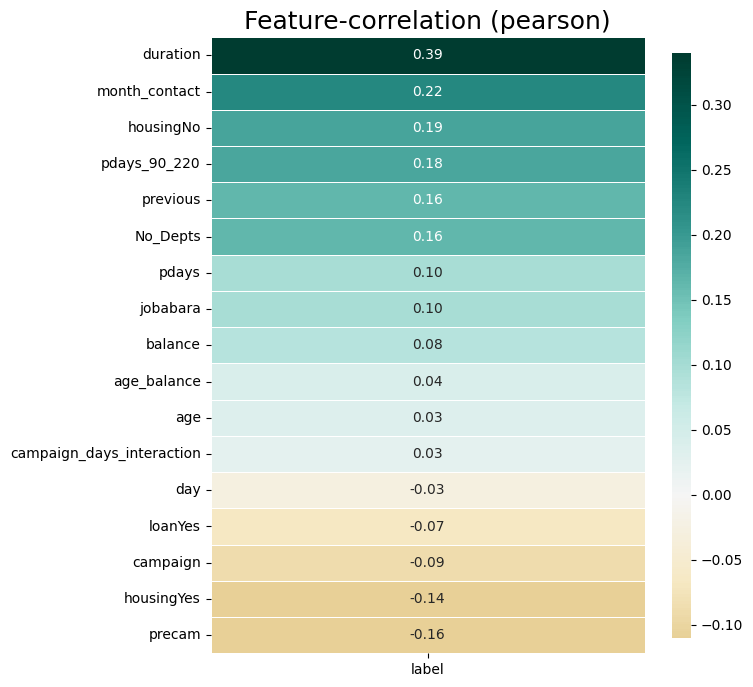

In [21]:
import klib

klib.corr_plot(data = df_trn[num_cols],
               target = df_trn['label'],
               figsize = (7, 8))

plt.show()

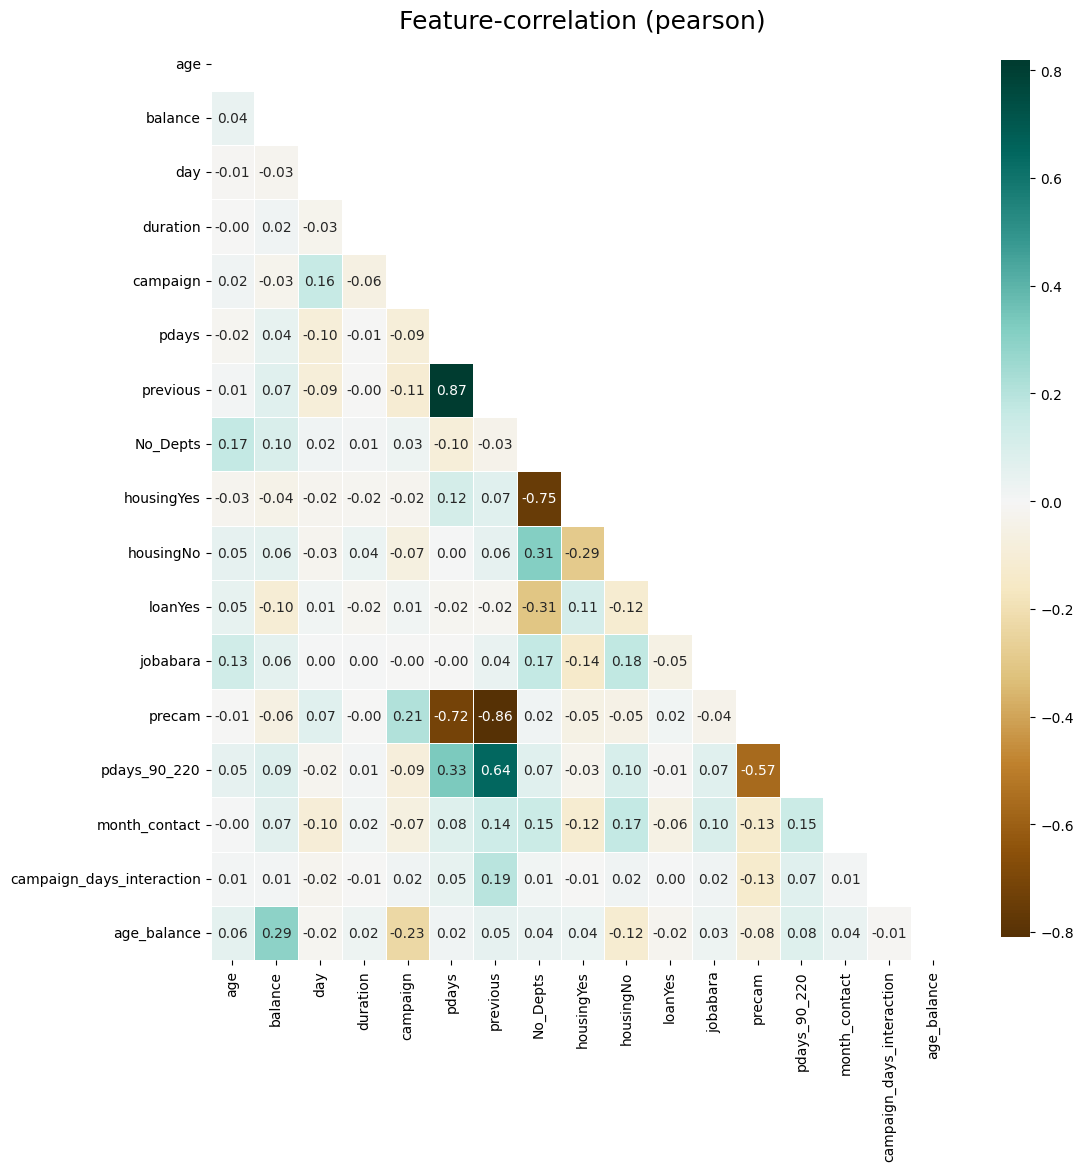

In [22]:
klib.corr_plot(data = df_trn[num_cols] ,figsize = (12, 12))
plt.show()

## EDA

* 수치형 변수

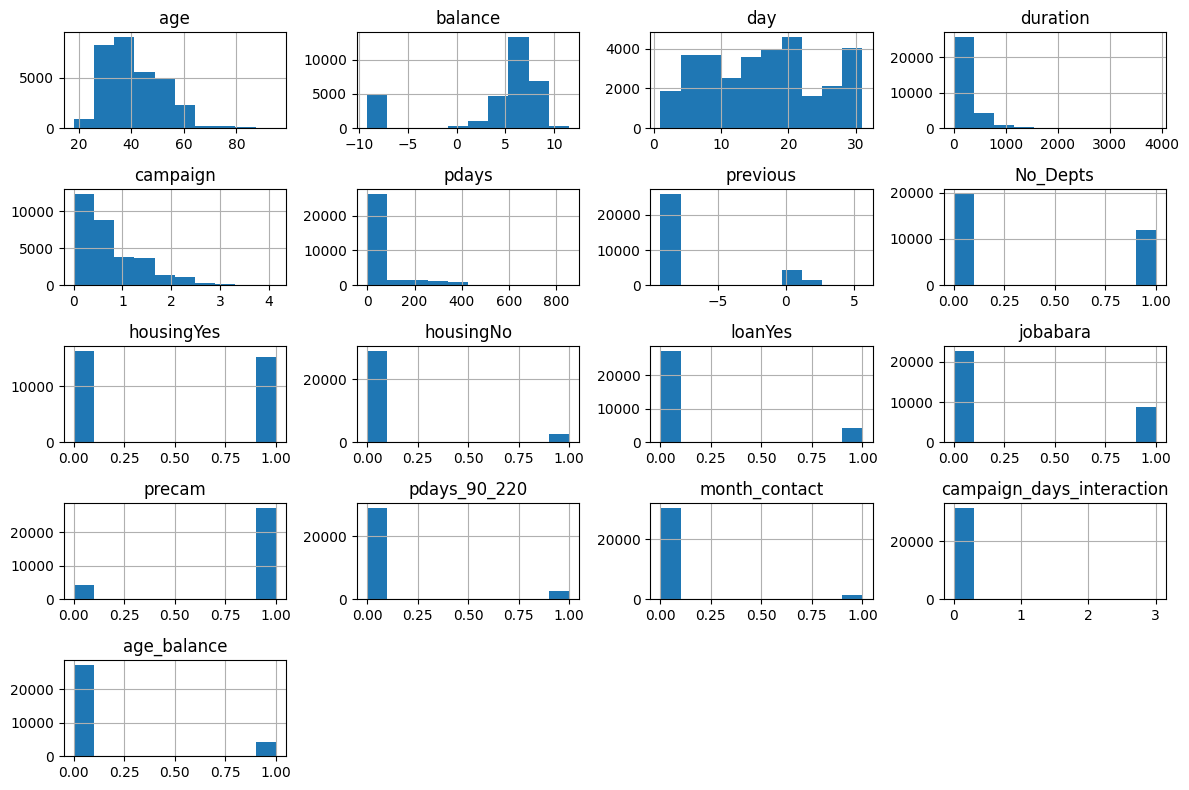

In [23]:
df_trn[num_cols].hist(figsize=(12,8))
plt.tight_layout()

* Binary Feature(이진분류 변수) 지정

In [24]:
yn_cols = [col for col in df_trn[cat_cols].columns if set(df_trn[col].unique()) <= {'yes', 'no'}]
not_yn_cols = [col for col in cat_cols if not set(df_trn[col].unique()) <= {'yes', 'no'}]

* Binary Feature 시각화

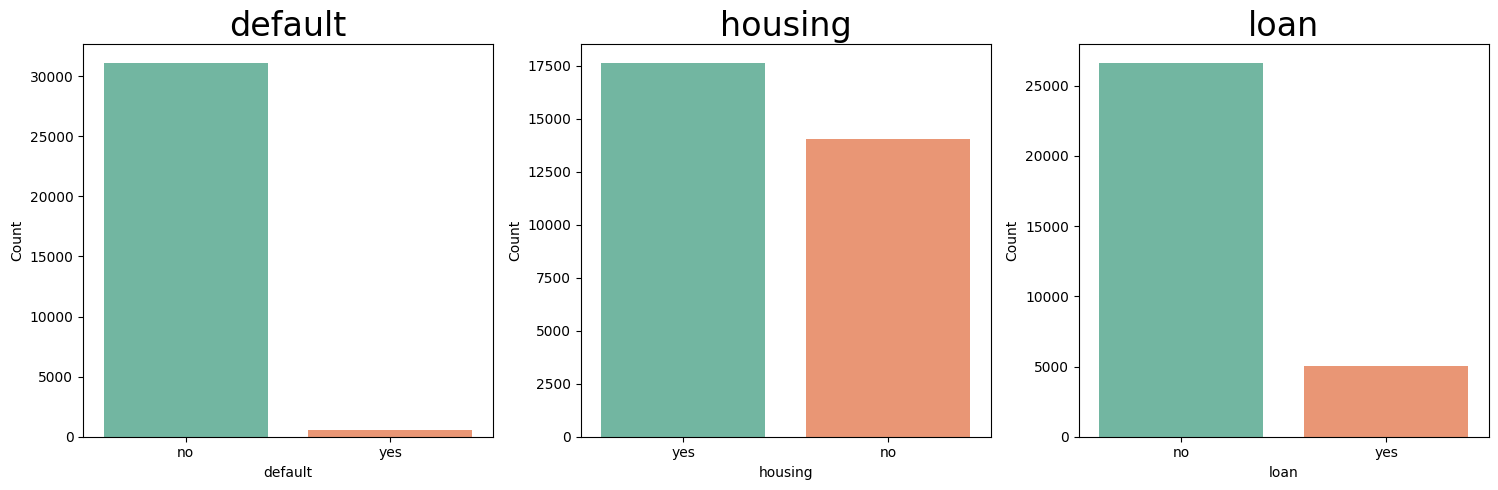

In [25]:
# 변수 개수와 행, 열의 수를 설정
n_cols = 7  # 한 행에 표시할 변수 개수 (여기서는 3개)
n_rows = (len(yn_cols) + n_cols - 1) // n_cols  # 필요한 행의 수 계산

# 전체 그림 크기 설정 (각 서브플롯의 크기를 고려해서 조정)
plt.figure(figsize=(n_cols * 5, n_rows * 5))

# 각 범주형 변수에 대해 countplot을 그립니다
for i, col in enumerate(yn_cols, 1):
    plt.subplot(n_rows, n_cols, i)  # 서브플롯 지정 (n_rows x n_cols)
    sns.countplot(x=col, data=df_trn, palette="Set2")
    plt.title(f'{col}', fontsize=24)
    plt.xlabel(col)
    plt.ylabel('Count')

# 레이아웃 조정
plt.tight_layout()
plt.show()

* Not Binary Feature 시각화

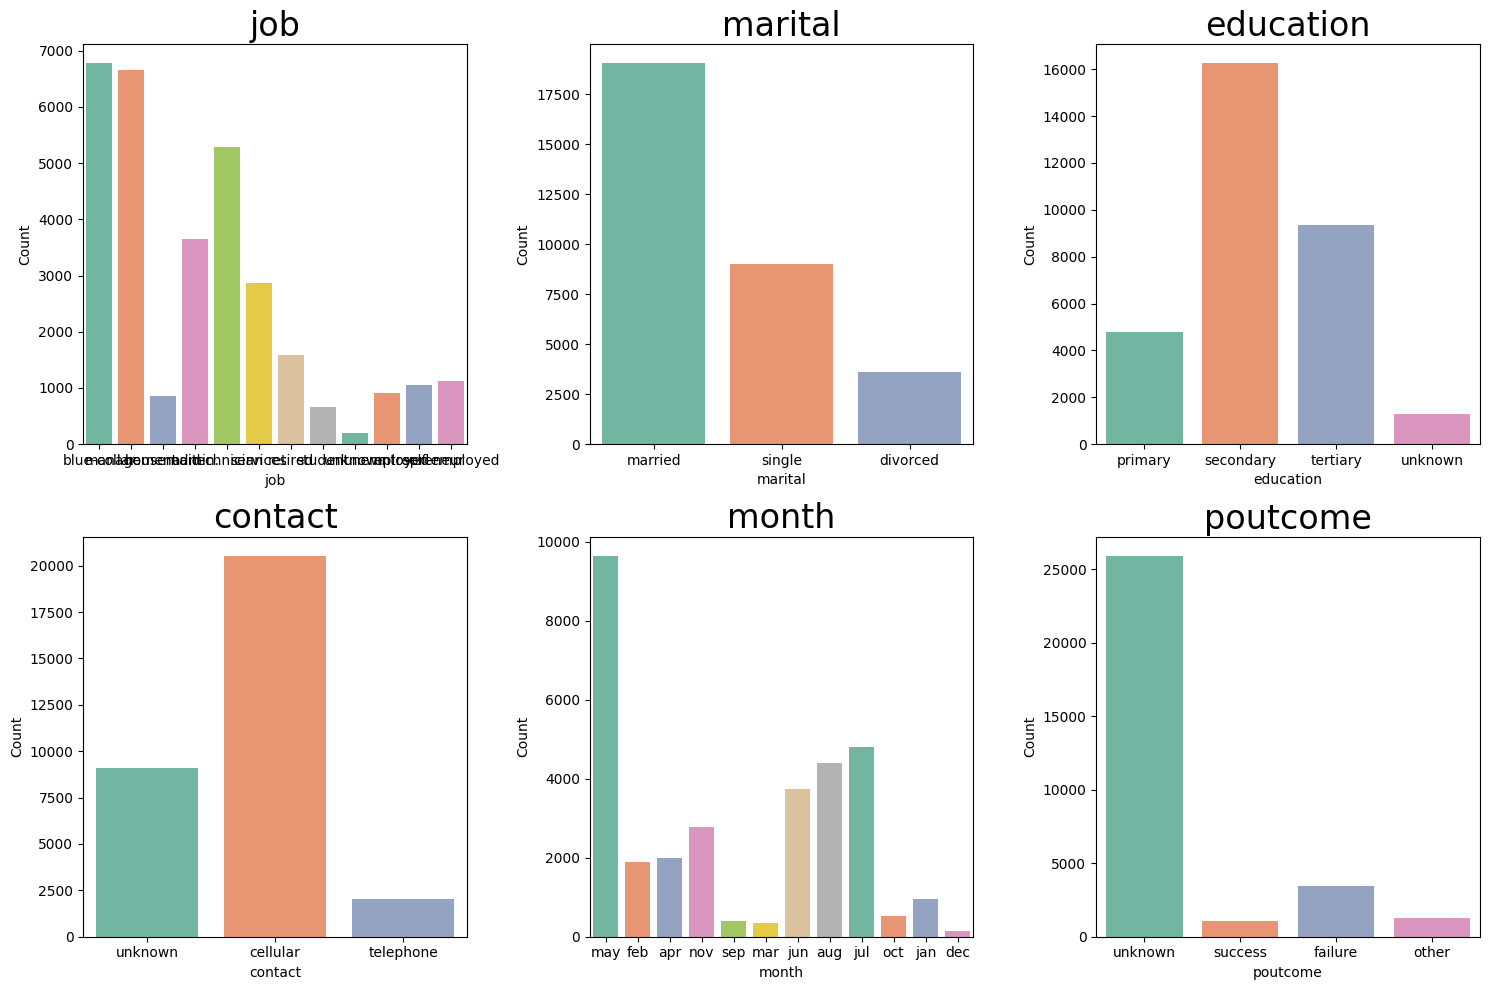

In [26]:
# 변수 개수와 행, 열의 수를 설정
n_cols = 3  # 한 행에 표시할 변수 개수 (여기서는 3개)
n_rows = (len(not_yn_cols) + n_cols - 1) // n_cols  # 필요한 행의 수 계산

# 전체 그림 크기 설정 (각 서브플롯의 크기를 고려해서 조정)
plt.figure(figsize=(n_cols * 5, n_rows * 5))

# 각 범주형 변수에 대해 countplot을 그립니다
for i, col in enumerate(not_yn_cols, 1):
    plt.subplot(n_rows, n_cols, i)  # 서브플롯 지정 (n_rows x n_cols)
    sns.countplot(x=col, data=df_trn, palette="Set2")
    plt.title(f'{col}', fontsize=24)
    plt.xlabel(col)
    plt.ylabel('Count')

# 레이아웃 조정
plt.tight_layout()
plt.show()

# 전처리

* Binary Feature Mapping

In [27]:
df_trn['default'] = df_trn['default'].apply(lambda x: 1 if x == 'yes' else 0)
df_trn['housing'] = df_trn['housing'].apply(lambda x: 1 if x == 'yes' else 0)
df_trn['loan'] = df_trn['loan'].apply(lambda x: 1 if x == 'yes' else 0)

df_tst['default'] = df_tst['default'].apply(lambda x: 1 if x == 'yes' else 0)
df_tst['housing'] = df_tst['housing'].apply(lambda x: 1 if x == 'yes' else 0)
df_tst['loan'] = df_tst['loan'].apply(lambda x: 1 if x == 'yes' else 0)

* Scailing & Encoding

In [28]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

num_pipeline = Pipeline([
    ('scaliing', MinMaxScaler())
])

cat_pipeline = Pipeline([
    ('encoding1', OneHotEncoder(sparse_output=False,handle_unknown='ignore'))
])

In [29]:
col_transformer = ColumnTransformer(
    [
        ('num', num_pipeline, num_cols),
        ('yn', 'passthrough', yn_cols), 
        ('not_yn', cat_pipeline, not_yn_cols)
    ], 
    remainder='drop', 
    verbose_feature_names_out=False, 
    # force_int_remainder_cols=False
)
col_transformer.set_output(transform='pandas')

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaliing', MinMaxScaler())]),
                                 ['age', 'balance', 'day', 'duration',
                                  'campaign', 'pdays', 'previous', 'No_Depts',
                                  'housingYes', 'housingNo', 'loanYes',
                                  'jobabara', 'precam', 'pdays_90_220',
                                  'month_contact', 'campaign_days_interaction',
                                  'age_balance']),
                                ('yn', 'passthrough',
                                 ['default', 'housing', 'loan']),
                                ('not_yn',
                                 Pipeline(steps=[('encoding1',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['job', 'marital', 'education', 'contact',
                                  'month', 'poutcome'])],
                  verbose_feature_names_out=False)

In [30]:
df_trn1 = col_transformer.fit_transform(df_trn)
df_tst1 = col_transformer.transform(df_tst)

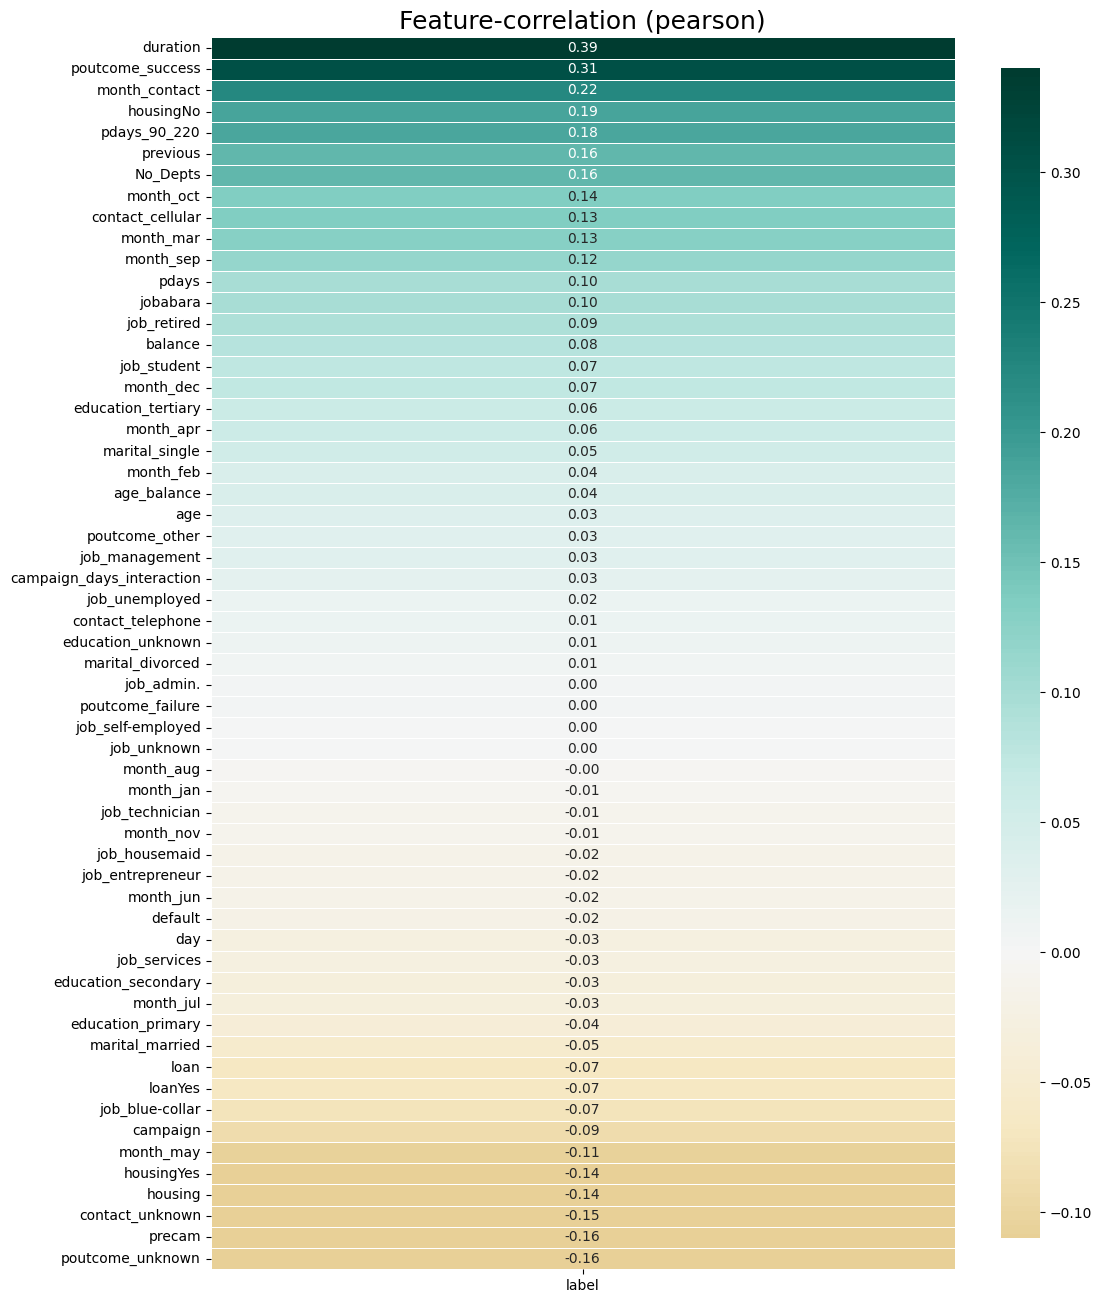

In [31]:
import klib

klib.corr_plot(data = df_trn1,
               target = df_trn['label'],
               figsize = (12, 16))

plt.show()

# Feature Selection

In [32]:
df_trn_preprocessed = pd.concat((df_trn1, df_trn['label']), axis=1)

In [33]:
X_train = df_trn_preprocessed.drop(columns=['label'])
y_train = df_trn['label']

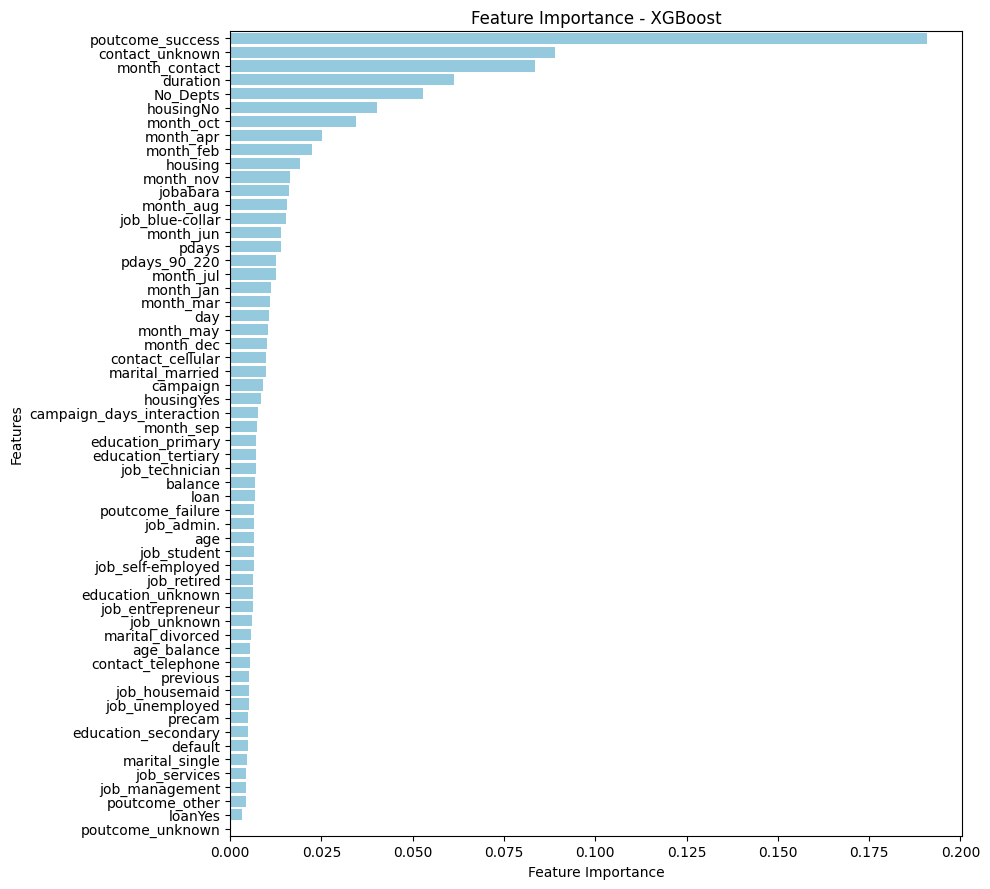

In [34]:
import xgboost as xgb  # XGBoost 모델 추가
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# XGBoost 모델 학습 (예시)
xgb_model = xgb.XGBClassifier(
    n_estimators=100,  # 트리 개수
    max_depth=6,       # 최대 트리 깊이
    learning_rate=0.1, # 학습률
    verbosity=0        # 학습 로그 최소화
)  # 하이퍼파라미터는 필요에 따라 조정
xgb_model.fit(X_train, y_train)  # X_train, y_train은 훈련 데이터

# XGBoost 피처 중요도 추출
xgb_feature_importance = xgb_model.feature_importances_

# XGBoost 데이터프레임
xgb_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance_XGBoost': xgb_feature_importance
})
xgb_importance_df = xgb_importance_df.sort_values(by='Importance_XGBoost', ascending=False)

# 시각화 (XGBoost 모델)
plt.figure(figsize=(10, 9))
sns.barplot(x='Importance_XGBoost', y='Feature', data=xgb_importance_df, color='skyblue')
plt.title("Feature Importance - XGBoost")
plt.xlabel("Feature Importance")
plt.ylabel("Features")

# 레이아웃 조정 및 표시
plt.tight_layout()
plt.show()

poutcome_unknown 제거 필요성 인지.

# Modeling

In [35]:
X_train = df_trn_preprocessed.drop(columns=['label','poutcome_unknown'])
y_train = df_trn['label']

X_test = df_tst1.drop(columns=['poutcome_unknown'])

In [36]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from imblearn.over_sampling import SMOTE


# XGBoost 모델
xgb_model = xgb.XGBClassifier()

# 그리드 서치에 사용할 하이퍼파라미터 범위 설정 (클래스 가중치 추가)
param_grid = {
    'n_estimators': [50, 100, 150],  # 트리의 개수
    'max_depth': [3, 6, 9],           # 트리의 깊이
    'learning_rate': [0.01, 0.1, 0.2], # 학습률
    'subsample': [0.8, 1.0],           # 샘플링 비율
    'colsample_bytree': [0.8, 1.0],     # 트리별 특성 샘플링 비율
    'scale_pos_weight': [1, 2, 3, 5]      # 클래스 불균형에 대한 가중치 (클래스 1에 대한 가중치 조정)
}

# 그리드 서치 수행 (f1 score 기준으로)
gcv = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=1, scoring='f1')
gcv.fit(X_train, y_train)

# 최적의 하이퍼파라미터 출력
print(f"Best parameters: {gcv.best_params_}")
print(f"Best score (F1): {gcv.best_score_}")

Fitting 3 folds for each of 432 candidates, totalling 1296 fits
Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100, 'scale_pos_weight': 3, 'subsample': 0.8}
Best score (F1): 0.6220541811502317


# 임계값 조정

* Best Parameter로 학습된 xgb의 Feature Importance 확인

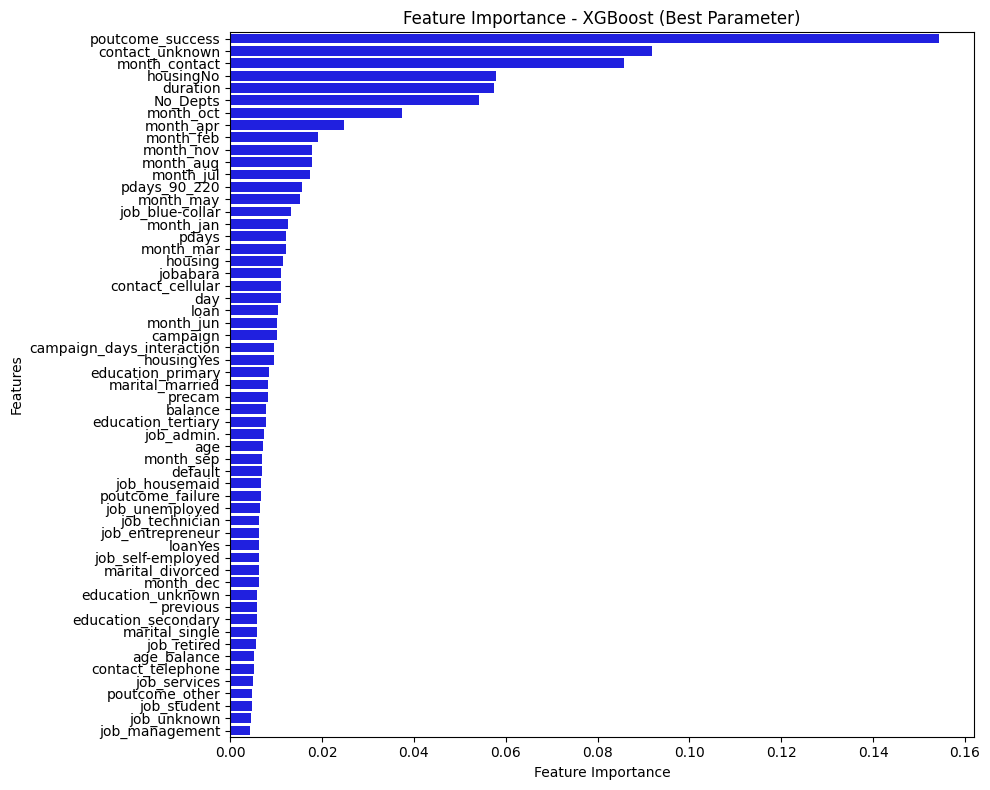

In [37]:
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 이미 분할된 학습 세트와 테스트 세트 사용 (X_train, y_train)

# 최적의 하이퍼파라미터
best_params = gcv.best_params_

# 최적의 파라미터로 고정된 XGBoost 모델 생성
fixed_xgb_model = xgb.XGBClassifier(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    learning_rate=best_params['learning_rate'],
    subsample=best_params['subsample'],
    colsample_bytree=best_params['colsample_bytree'],
    scale_pos_weight=best_params['scale_pos_weight']
)

# 고정된 모델을 원본 데이터로 학습
fixed_xgb_model.fit(X_train, y_train)

# 고정된 모델로 피처 중요도 추출
xgb_feature_importance = fixed_xgb_model.feature_importances_

# 데이터프레임 생성 (XGBoost의 중요도)
feature_names = X_train.columns  # 피처 이름
xgb_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance_XGBoost': xgb_feature_importance
})
xgb_importance_df = xgb_importance_df.sort_values(by='Importance_XGBoost', ascending=False)

# XGBoost 중요도 시각화
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance_XGBoost', y='Feature', data=xgb_importance_df, color='blue')
plt.title("Feature Importance - XGBoost (Best Parameter)")
plt.xlabel("Feature Importance")
plt.ylabel("Features")

# 레이아웃 조정 및 표시
plt.tight_layout()
plt.show()

* Cross-Validation을 활용해 Optimal Threshold 구하기

Optimal Threshold: 0.52


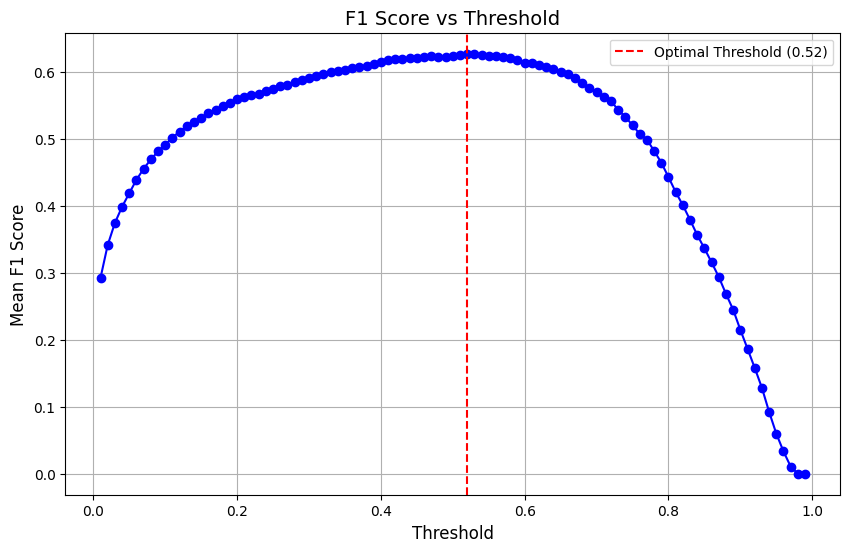

In [38]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# 교차 검증을 위한 KFold 생성
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 최적 임계값을 찾기 위한 리스트
best_thresholds = []
thresholds = [i * 0.01 for i in range(1, 100)]  # 임계값 후보 (0.01부터 0.99까지)

# F1 점수를 저장할 리스트
f1_scores_per_threshold = {threshold: [] for threshold in thresholds}

# 교차 검증을 통해 최적 임계값을 찾음
for train_idx, val_idx in cv.split(X_train, y_train):  # 원본 데이터 사용
    # iloc을 사용하여 인덱스 기반으로 데이터를 선택
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # 모델 학습
    fixed_xgb_model.fit(X_train_fold, y_train_fold)
    
    # 예측 확률 출력
    y_pred_prob = fixed_xgb_model.predict_proba(X_val_fold)[:, 1]  # 양성 클래스 확률

    # 다양한 임계값에서 평가
    for threshold in thresholds:
        y_pred_bin = (y_pred_prob >= threshold).astype(int)  # 임계값 기준 이진 분류
        f1 = f1_score(y_val_fold, y_pred_bin)  # F1 스코어 계산
        f1_scores_per_threshold[threshold].append(f1)

# 평균 F1 점수 계산
mean_f1_scores = {threshold: np.mean(f1_scores_per_threshold[threshold]) for threshold in thresholds}

# 최적 임계값 찾기 (평균 F1 점수가 최대인 임계값)
optimal_threshold = max(mean_f1_scores, key=mean_f1_scores.get)
print(f'Optimal Threshold: {optimal_threshold}')

# F1 점수의 변화를 시각화
plt.figure(figsize=(10, 6))
plt.plot(thresholds, [mean_f1_scores[threshold] for threshold in thresholds], marker='o', linestyle='-', color='b')
plt.title('F1 Score vs Threshold', fontsize=14)
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Mean F1 Score', fontsize=12)
plt.grid(True)
plt.axvline(x=optimal_threshold, color='r', linestyle='--', label=f'Optimal Threshold ({optimal_threshold:.2f})')
plt.legend()
plt.show()

* Positive Class 분포 확인

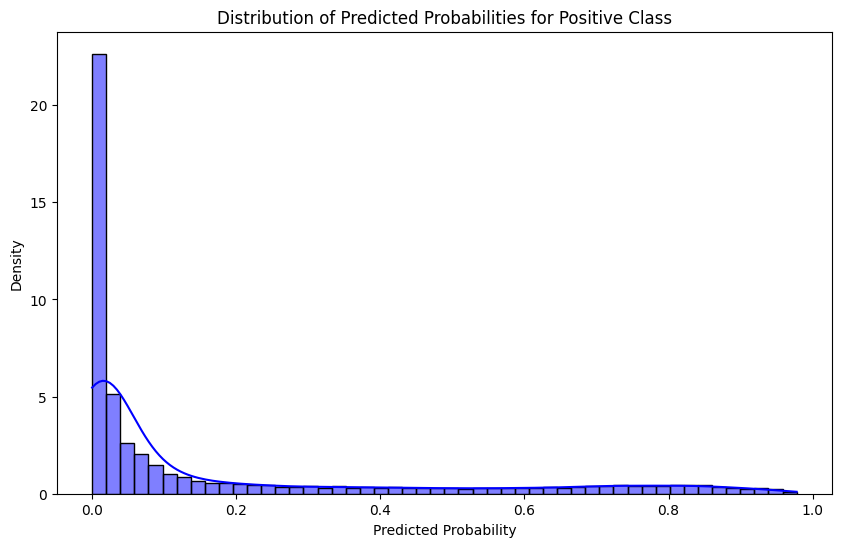

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# 테스트 데이터에 대해 예측 확률 계산
pred_probs = fixed_xgb_model.predict_proba(X_test)

# 예측 확률에서 양성 클래스(1)에 대한 확률 추출
positive_class_probs = pred_probs[:, 1]

# 히스토그램으로 예측 확률 시각화
plt.figure(figsize=(10, 6))
sns.histplot(positive_class_probs, bins=50, kde=True, color='blue', stat='density')

# 그래프 꾸미기
plt.title('Distribution of Predicted Probabilities for Positive Class')
plt.xlabel('Predicted Probability')
plt.ylabel('Density')
plt.show()

* Optimal Threshold 적용

In [40]:
from sklearn.metrics import f1_score
import numpy as np

# 임계값을 적용하는 함수
def apply_threshold(pred_probs, threshold=0.55):
    return (pred_probs[:, 1] >= threshold).astype(int)

# 임계값 조정 
threshold = 0.52
y_pred_thr = apply_threshold(pred_probs, threshold)

# 제출

In [41]:
df_submission = pd.read_csv('submission_example.csv')

In [42]:
df_submission.head()

,ID,label
0,test00001,0
1,test00002,0
2,test00003,0
3,test00004,0
4,test00005,0


In [43]:
df_submission['label'] = y_pred_thr

In [44]:
df_submission['label'].value_counts()

label
0    11491
1     2073
Name: count, dtype: int64

In [45]:
# 새로운 파일로 저장하기
filename = 'xgboost.csv'
df_submission.to_csv(filename, index=False)

-----------------------------------------

# **LGBM**

-----------------------------------------

In [46]:
df_trn = pd.read_csv('train.csv').copy()
df_tst = pd.read_csv('test.csv').copy()
df_sub = pd.read_csv('submission_example.csv').copy()

* 'ID' 변수 제거

In [47]:
df_trn.drop(columns=['ID'], inplace=True)

# Feature Engineering

In [48]:
value_month=['mar','jun','sep','dec']
df_trn['month_contact'] = ((df_trn['month'].isin(value_month)) & (df_trn['contact'] == 'cellular')).astype(int)
df_tst['month_contact'] = ((df_tst['month'].isin(value_month)) & (df_tst['contact'] == 'cellular')).astype(int)

In [49]:
df_trn['No_Debts'] = ((df_trn['default'] == 'no') & (df_trn['loan'] == 'no') & (df_trn['housing'] == 'no')).astype(int) 
df_tst['No_Debts'] = ((df_tst['default'] == 'no') & (df_tst['loan'] == 'no') & (df_tst['housing'] == 'no')).astype(int)

In [50]:
df_trn['con_du'] = ((df_trn['contact'] == 'unknown') & (df_trn['duration'] <= 517.5)).astype(int) 
df_tst['con_du'] = ((df_tst['contact'] == 'unknown') & (df_tst['duration'] <= 517.5)).astype(int)

In [51]:
df_trn['campaign'] = np.log(df_trn['campaign'])
df_tst['campaign'] = np.log(df_tst['campaign'])

In [52]:
df_trn['balance'] = np.log(df_trn['balance'].apply(lambda x: 0.0001 if x <= 0 else x))
df_tst['balance'] = np.log(df_tst['balance'].apply(lambda x: 0.0001 if x <= 0 else x))

# 상관관계 확인

In [53]:
total_cols = [x for x in df_trn.columns]

y_cols = ['label']

cat_cols = df_trn.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = [x for x in df_trn.columns if x not in y_cols+cat_cols]

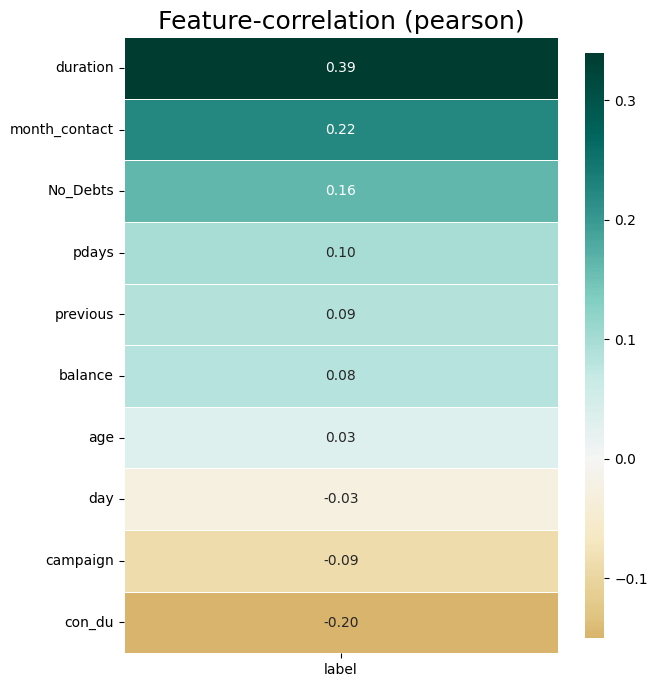

In [54]:
import klib

klib.corr_plot(data = df_trn[num_cols],
               target = df_trn['label'],
               figsize = (7, 8))

plt.show()

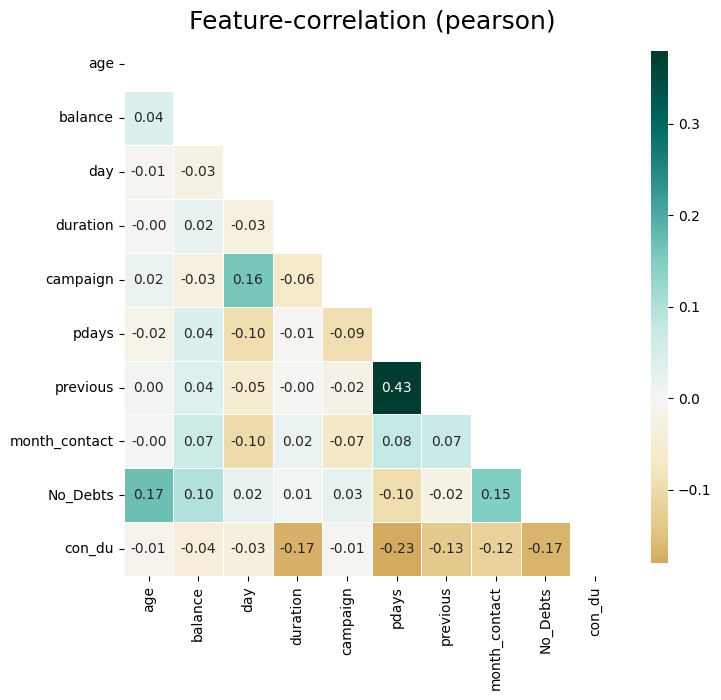

In [55]:
klib.corr_plot(data = df_trn[num_cols] ,figsize = (8, 7))
plt.show()

# EDA

* 수치형 변수 시각화

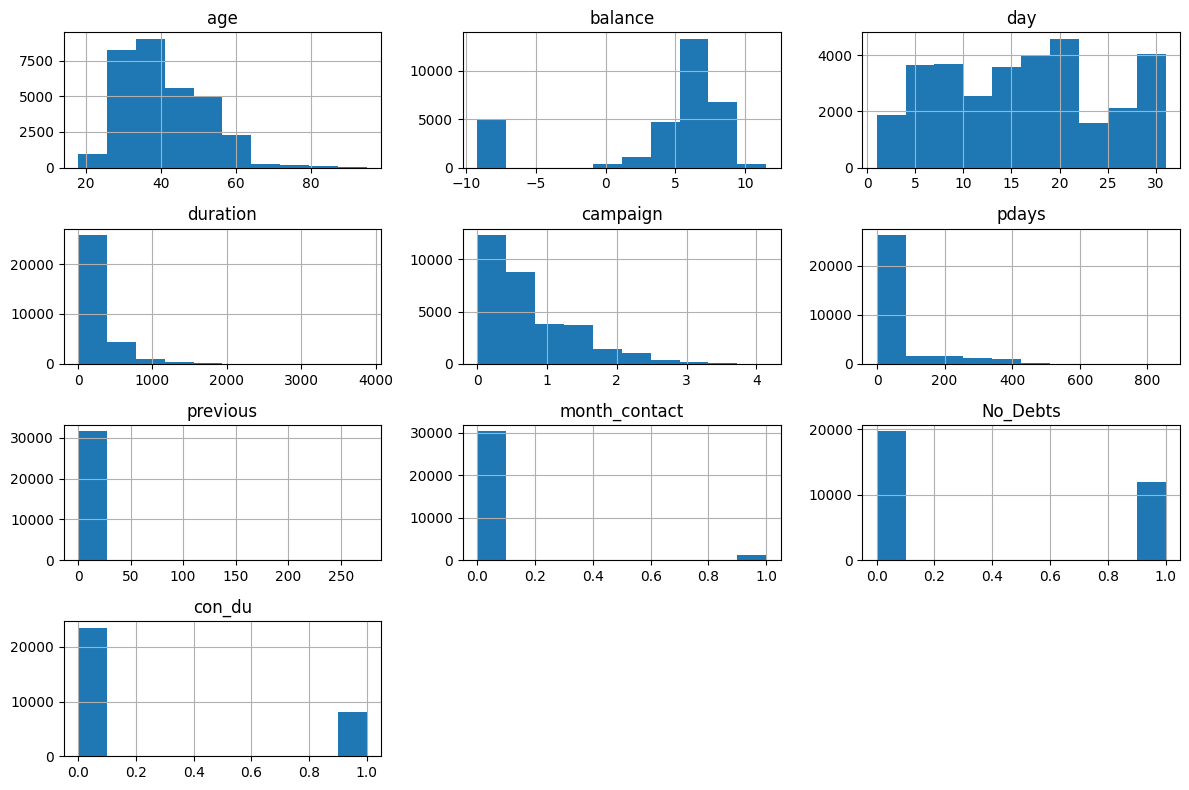

In [56]:
df_trn[num_cols].hist(figsize=(12,8))
plt.tight_layout()

* Binary Feature(이진분류 변수) 지정

In [57]:
yn_cols = [col for col in df_trn[cat_cols].columns if set(df_trn[col].unique()) <= {'yes', 'no'}]
not_yn_cols = [col for col in cat_cols if not set(df_trn[col].unique()) <= {'yes', 'no'}]

* Binary Feature 시각화

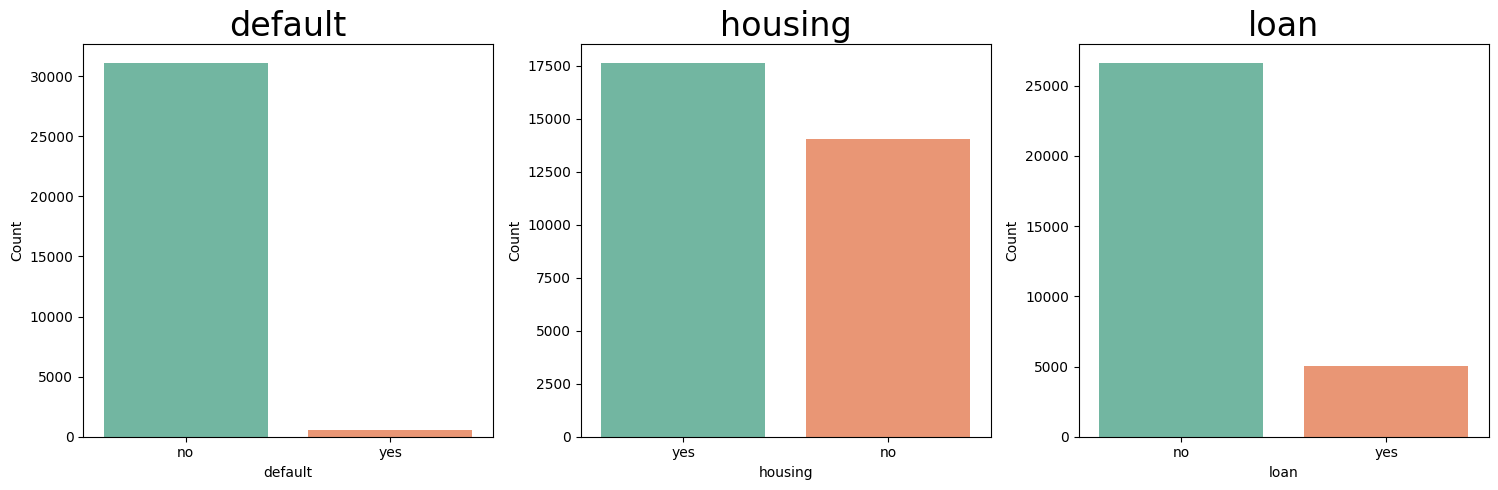

In [58]:
# 변수 개수와 행, 열의 수를 설정
n_cols = 7  # 한 행에 표시할 변수 개수 (여기서는 3개)
n_rows = (len(yn_cols) + n_cols - 1) // n_cols  # 필요한 행의 수 계산

# 전체 그림 크기 설정 (각 서브플롯의 크기를 고려해서 조정)
plt.figure(figsize=(n_cols * 5, n_rows * 5))

# 각 범주형 변수에 대해 countplot을 그립니다
for i, col in enumerate(yn_cols, 1):
    plt.subplot(n_rows, n_cols, i)  # 서브플롯 지정 (n_rows x n_cols)
    sns.countplot(x=col, data=df_trn, palette="Set2")
    plt.title(f'{col}', fontsize=24)
    plt.xlabel(col)
    plt.ylabel('Count')

# 레이아웃 조정
plt.tight_layout()
plt.show()

* Not Binary Feature 시각화

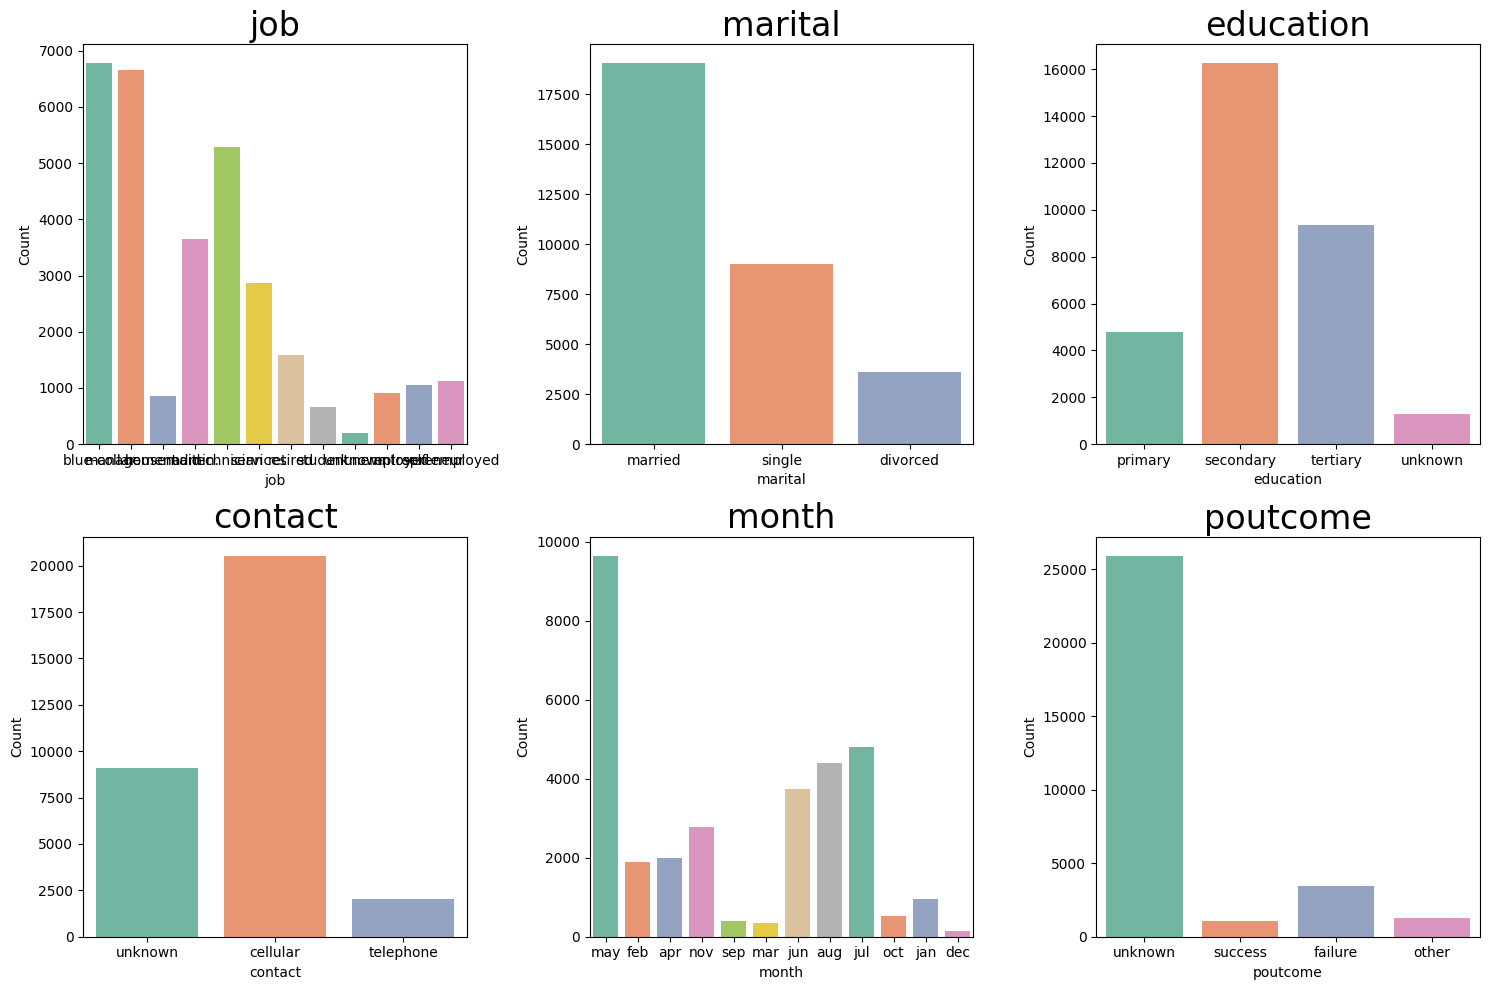

In [59]:
# 변수 개수와 행, 열의 수를 설정
n_cols = 3  # 한 행에 표시할 변수 개수 (여기서는 3개)
n_rows = (len(not_yn_cols) + n_cols - 1) // n_cols  # 필요한 행의 수 계산

# 전체 그림 크기 설정 (각 서브플롯의 크기를 고려해서 조정)
plt.figure(figsize=(n_cols * 5, n_rows * 5))

# 각 범주형 변수에 대해 countplot을 그립니다
for i, col in enumerate(not_yn_cols, 1):
    plt.subplot(n_rows, n_cols, i)  # 서브플롯 지정 (n_rows x n_cols)
    sns.countplot(x=col, data=df_trn, palette="Set2")
    plt.title(f'{col}', fontsize=24)
    plt.xlabel(col)
    plt.ylabel('Count')

# 레이아웃 조정
plt.tight_layout()
plt.show()

# PreProcessing

* Binary Feature Mapping

In [60]:
df_trn['default'] = df_trn['default'].apply(lambda x: 1 if x == 'yes' else 0)
df_trn['housing'] = df_trn['housing'].apply(lambda x: 1 if x == 'yes' else 0)
df_trn['loan'] = df_trn['loan'].apply(lambda x: 1 if x == 'yes' else 0)

df_tst['default'] = df_tst['default'].apply(lambda x: 1 if x == 'yes' else 0)
df_tst['housing'] = df_tst['housing'].apply(lambda x: 1 if x == 'yes' else 0)
df_tst['loan'] = df_tst['loan'].apply(lambda x: 1 if x == 'yes' else 0)

* Scailing & Encoding

In [61]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

num_pipeline = Pipeline([
    ('scaliing', MinMaxScaler())
])

cat_pipeline = Pipeline([
    ('encoding1', OneHotEncoder(sparse_output=False))
])

In [62]:
col_transformer = ColumnTransformer(
    [
        ('num', num_pipeline, num_cols),
        ('yn', 'passthrough', yn_cols),
        ('not_yn', cat_pipeline, not_yn_cols)
    ], 
    remainder='drop', 
    verbose_feature_names_out=False, 
    # force_int_remainder_cols=False
)
col_transformer.set_output(transform='pandas')

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaliing', MinMaxScaler())]),
                                 ['age', 'balance', 'day', 'duration',
                                  'campaign', 'pdays', 'previous',
                                  'month_contact', 'No_Debts', 'con_du']),
                                ('yn', 'passthrough',
                                 ['default', 'housing', 'loan']),
                                ('not_yn',
                                 Pipeline(steps=[('encoding1',
                                                  OneHotEncoder(sparse_output=False))]),
                                 ['job', 'marital', 'education', 'contact',
                                  'month', 'poutcome'])],
                  verbose_feature_names_out=False)

In [63]:
df_trn1 = col_transformer.fit_transform(df_trn)
df_tst1 = col_transformer.transform(df_tst)

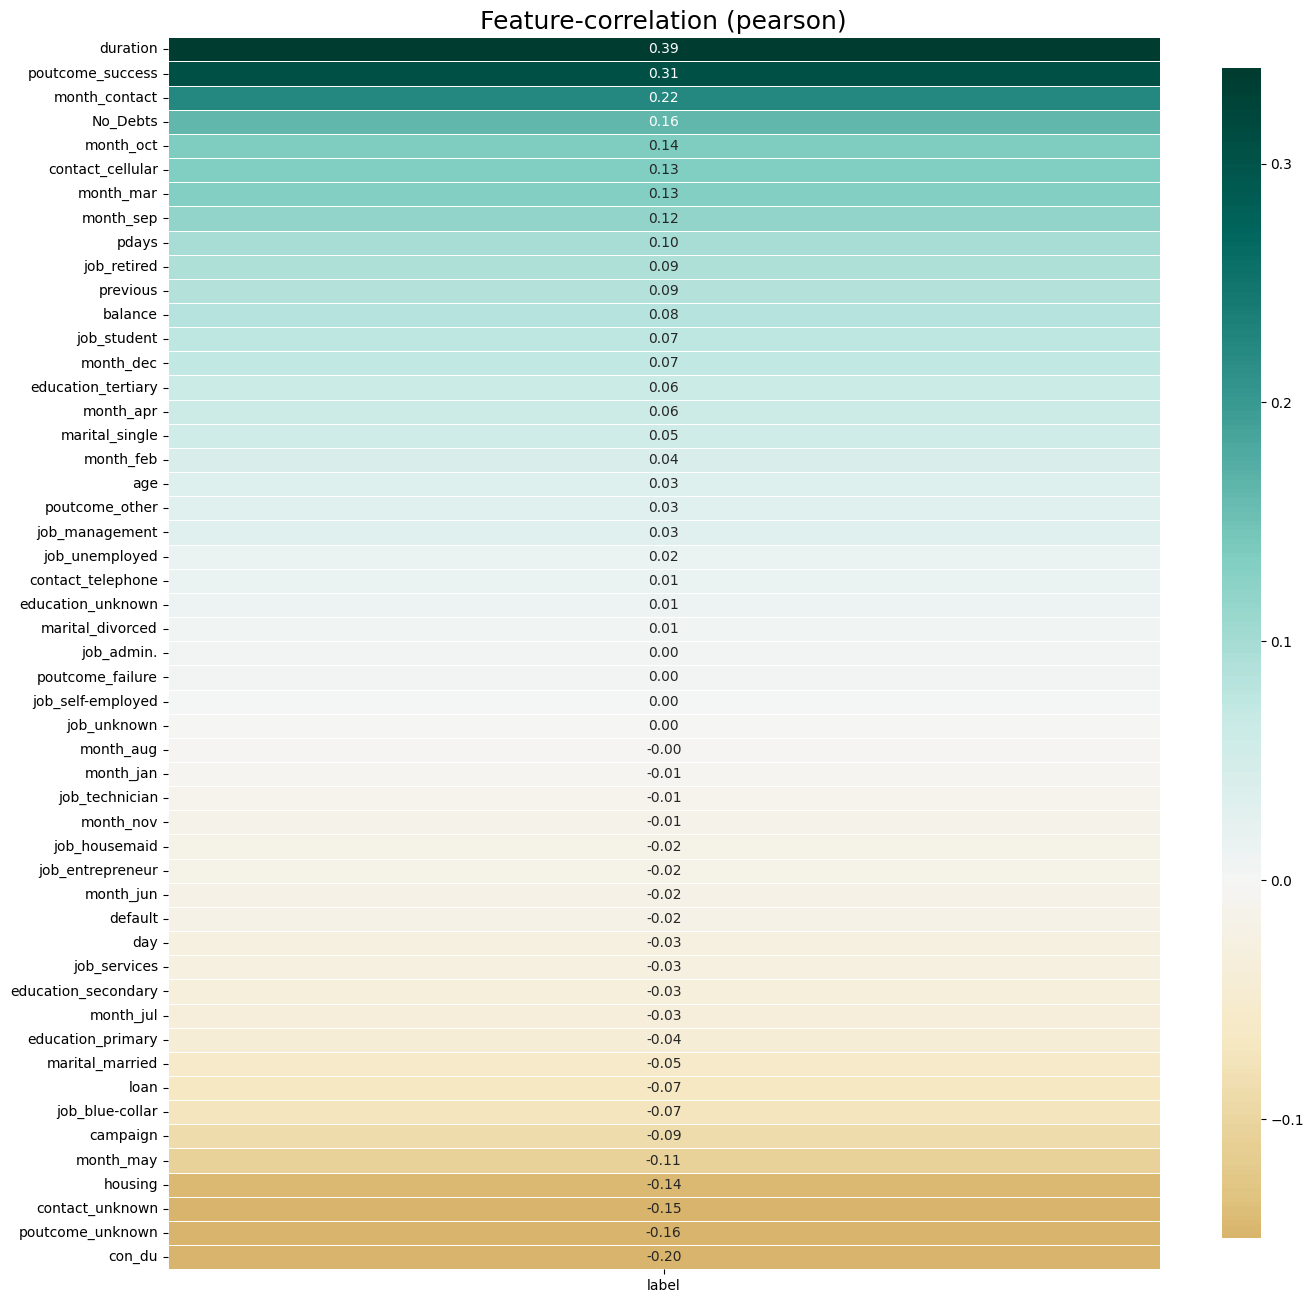

In [64]:
import klib

klib.corr_plot(data = df_trn1,
               target = df_trn['label'],
               figsize = (16, 16))

plt.show()

# Feature Selection

In [65]:
df_trn_preprocessed = pd.concat((df_trn1, df_trn['label']), axis=1)

In [66]:
X_train = df_trn_preprocessed.drop(columns=['label'])
y_train = df_trn['label']

X_test = df_tst1

[LightGBM] [Info] Number of positive: 3702, number of negative: 27945
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002696 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1025
[LightGBM] [Info] Number of data points in the train set: 31647, number of used features: 51
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.116978 -> initscore=-2.021365
[LightGBM] [Info] Start training from score -2.021365
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

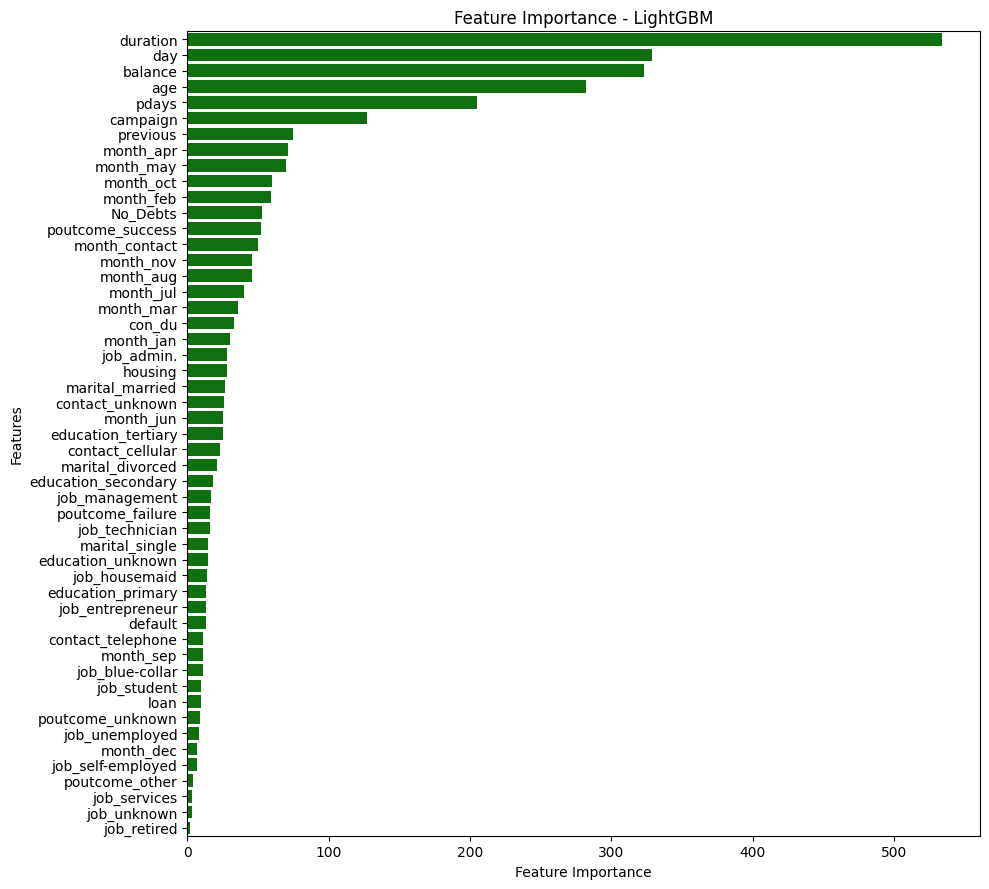

In [67]:
import lightgbm as lgb  # LightGBM 모델 추가
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# LightGBM 모델 학습 (예시)
lgb_model = lgb.LGBMClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)  # 하이퍼파라미터는 필요에 따라 조정
lgb_model.fit(X_train, y_train)  # X_train, y_train은 훈련 데이터

# LightGBM 피처 중요도 추출
lgb_feature_importance = lgb_model.feature_importances_

# LightGBM 데이터프레임
lgb_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance_LightGBM': lgb_feature_importance
})
lgb_importance_df = lgb_importance_df.sort_values(by='Importance_LightGBM', ascending=False)

# 시각화 (LightGBM 모델)
plt.figure(figsize=(10, 9))
sns.barplot(x='Importance_LightGBM', y='Feature', data=lgb_importance_df, color='green')
plt.title("Feature Importance - LightGBM")
plt.xlabel("Feature Importance")
plt.ylabel("Features")

# 레이아웃 조정 및 표시
plt.tight_layout()
plt.show()

# Modeling

In [68]:
X_train = df_trn_preprocessed.drop(columns=['label'])
y_train = df_trn['label']

X_test = df_tst1

* 데이터 불균형 해소를 위한 Train Data OverSampling

In [69]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [70]:
from sklearn.model_selection import GridSearchCV
import lightgbm as lgb

# 1. LightGBM 모델 생성
lgb_model = lgb.LGBMClassifier(random_state=42)

# 2. GridSearchCV 설정 (하이퍼파라미터 그리드)
param_grid = {
    'num_leaves': [31, 50, 100],     # LightGBM의 num_leaves
    'max_depth': [-1, 5, 10],        # LightGBM의 max_depth
    'learning_rate': [0.01, 0.1, 0.2], # LightGBM의 learning_rate
    'n_estimators': [100, 200, 300], # 트리의 개수
    'scale_pos_weight': [1, 2, 5, 10], # 클래스 불균형 조정
    'subsample': [0.8, 1.0],         # 각 트리에 사용할 데이터 샘플 비율
    'colsample_bytree': [0.8, 1.0]   # 각 트리에 사용할 피처 샘플 비율
}

# 3. GridSearchCV 수행
gcv = GridSearchCV(lgb_model,               # 모델
                   param_grid=param_grid,   # 하이퍼파라미터
                   cv=3,                    # 교차 검증
                   scoring='f1',            # 평가 지표
                   n_jobs=-1)               # 모든 코어 사용

# 4. 모델 학습
gcv.fit(X_train_resampled, y_train_resampled)

# 5. 최적 파라미터 출력
print('Final Params:', gcv.best_params_)

# 6. 최고의 성능 출력
print('Best Score:', gcv.best_score_)

# 7. 테스트 데이터에 대한 예측
y_pred = gcv.predict(X_test)

[LightGBM] [Info] Number of positive: 27945, number of negative: 27945
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010440 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11619
[LightGBM] [Info] Number of data points in the train set: 55890, number of used features: 51
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Final Params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 100, 'num_leaves': 100, 'scale_pos_weight': 2, 'subsample': 0.8}
Best Score: 0.9228534311003257


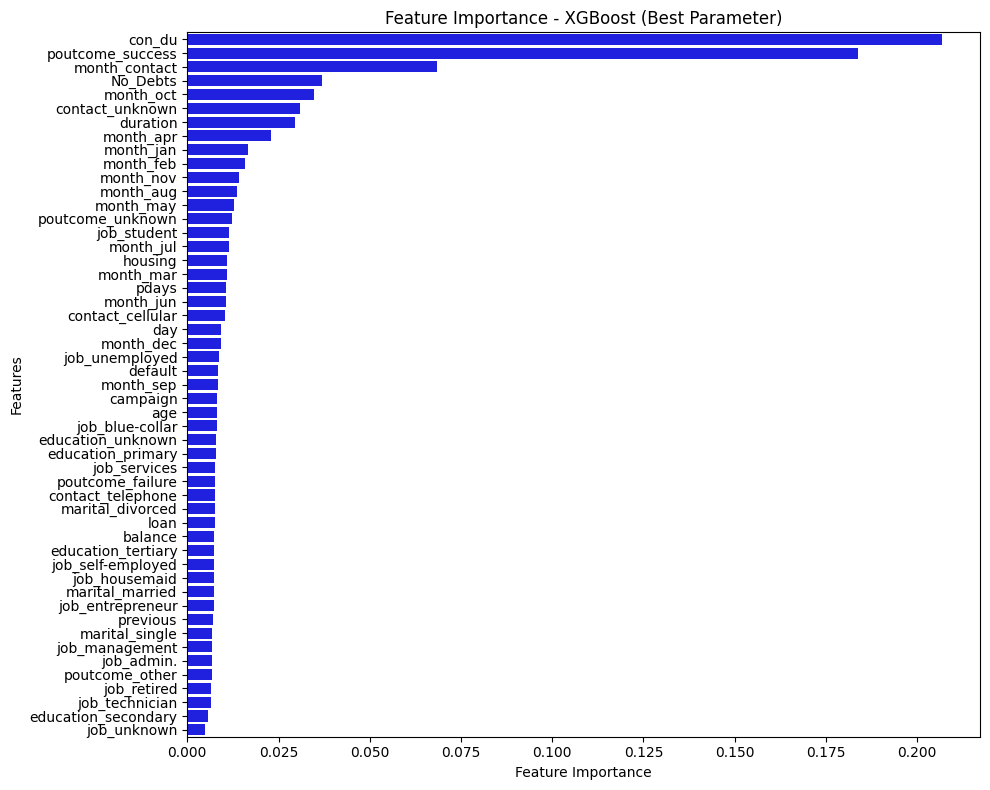

In [71]:
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 이미 분할된 학습 세트와 테스트 세트 사용 (X_train, y_train)

# 최적의 하이퍼파라미터
best_params = gcv.best_params_

# 최적의 파라미터로 고정된 XGBoost 모델 생성
fixed_xgb_model = xgb.XGBClassifier(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    learning_rate=best_params['learning_rate'],
    subsample=best_params['subsample'],
    colsample_bytree=best_params['colsample_bytree'],
    scale_pos_weight=best_params['scale_pos_weight']
)

# 고정된 모델을 원본 데이터로 학습
fixed_xgb_model.fit(X_train, y_train)

# 고정된 모델로 피처 중요도 추출
xgb_feature_importance = fixed_xgb_model.feature_importances_

# 데이터프레임 생성 (XGBoost의 중요도)
feature_names = X_train.columns  # 피처 이름
xgb_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance_XGBoost': xgb_feature_importance
})
xgb_importance_df = xgb_importance_df.sort_values(by='Importance_XGBoost', ascending=False)

# XGBoost 중요도 시각화
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance_XGBoost', y='Feature', data=xgb_importance_df, color='blue')
plt.title("Feature Importance - XGBoost (Best Parameter)")
plt.xlabel("Feature Importance")
plt.ylabel("Features")

# 레이아웃 조정 및 표시
plt.tight_layout()
plt.show()

# 제출

In [72]:
df_submission = pd.read_csv('submission_example.csv')

In [73]:
df_submission.head()

,ID,label
0,test00001,0
1,test00002,0
2,test00003,0
3,test00004,0
4,test00005,0


In [74]:
df_submission['label'] = y_pred_thr

In [75]:
df_submission['label'].value_counts()

label
0    11491
1     2073
Name: count, dtype: int64

In [76]:
# 새로운 파일로 저장하기
filename = 'lgbm.csv'
df_submission.to_csv(filename, index=False)

##### 

---------------

# **CatBoost**

--------------

In [77]:
df_trn = pd.read_csv('train.csv').copy()
df_tst = pd.read_csv('test.csv').copy()
df_sub = pd.read_csv('submission_example.csv').copy()

* 'ID' 변수 삭제

In [78]:
df_trn.drop(columns=['ID'], inplace=True)

# Feature Engineering

In [79]:
# 4분위 수 계산
quartiles = df_trn['balance'].quantile([0.25, 0.5, 0.75]).values

# 새로운 범주를 생성하는 함수 정의
def categorize_balance(balance):
    if balance <= quartiles[0]:
        return 'Q1'
    elif balance <= quartiles[1]:
        return 'Q2'
    elif balance <= quartiles[2]:
        return 'Q3'
    else:
        return 'Q4'

# 새로운 열을 df_trn에 추가
df_trn['balance_cat'] = df_trn['balance'].apply(categorize_balance)
df_tst['balance_cat'] = df_tst['balance'].apply(categorize_balance)

df_trn['poutcome_balance'] = ((df_trn['poutcome']) + '/' + (df_trn['balance_cat'])).astype('category')
df_tst['poutcome_balance'] = ((df_tst['poutcome']) + '/' + (df_tst['balance_cat'])).astype('category')

In [80]:
#duration 범주화
df_trn['duration_category'] = pd.qcut(df_trn['duration'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4']).astype('category')
df_tst['duration_category'] = pd.qcut(df_tst['duration'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4']).astype('category')

df_trn['contact_duration'] = ((df_trn['contact']).astype(str) + '/' + (df_trn['duration_category']).astype(str)).astype('category')
df_tst['contact_duration'] = ((df_tst['contact']).astype(str) + '/' + (df_tst['duration_category']).astype(str)).astype('category')

* 불필요한 피처 삭제

In [81]:
df_trn.drop(columns=['balance_cat','duration_category'], inplace=True)
df_tst.drop(columns=['balance_cat','duration_category'], inplace=True)

* new_cols에 추가

In [82]:
new_cols = []

new_cols.append('contact_duration')
new_cols.append('poutcome_balance')

## 상관관계 확인

In [83]:
total_cols = [x for x in df_trn.columns]

y_cols = ['label']

cat_cols = df_trn.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols = [x for x in cat_cols if x not in new_cols]
num_cols = [x for x in df_trn.columns if x not in y_cols+cat_cols+new_cols]

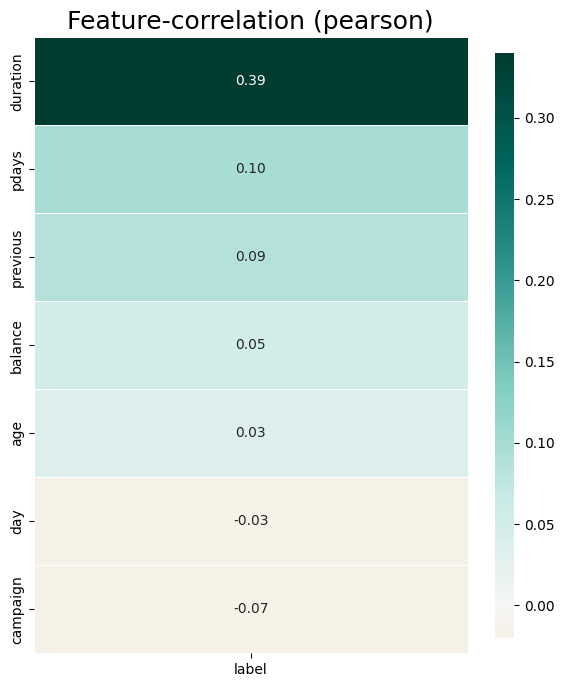

In [84]:
import klib

klib.corr_plot(data = df_trn[num_cols],
               target = df_trn['label'],
               figsize = (7, 8))

plt.show()

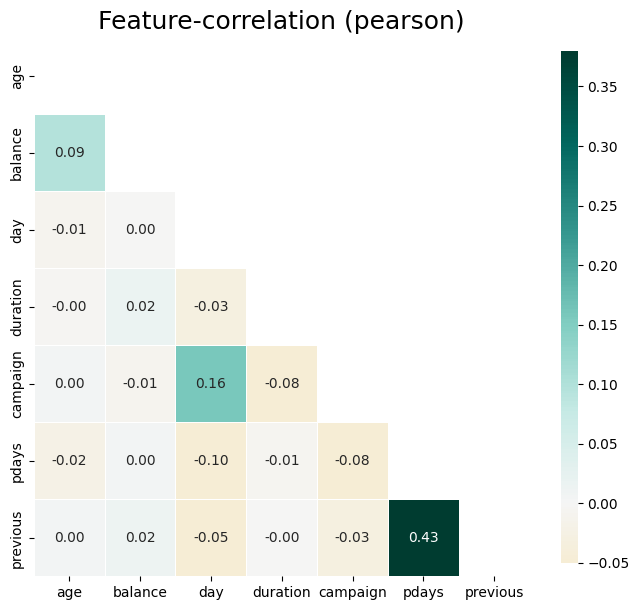

In [85]:
klib.corr_plot(data = df_trn[num_cols] ,figsize = (8, 7))
plt.show()

# EDA

* 수치형 변수 시각화

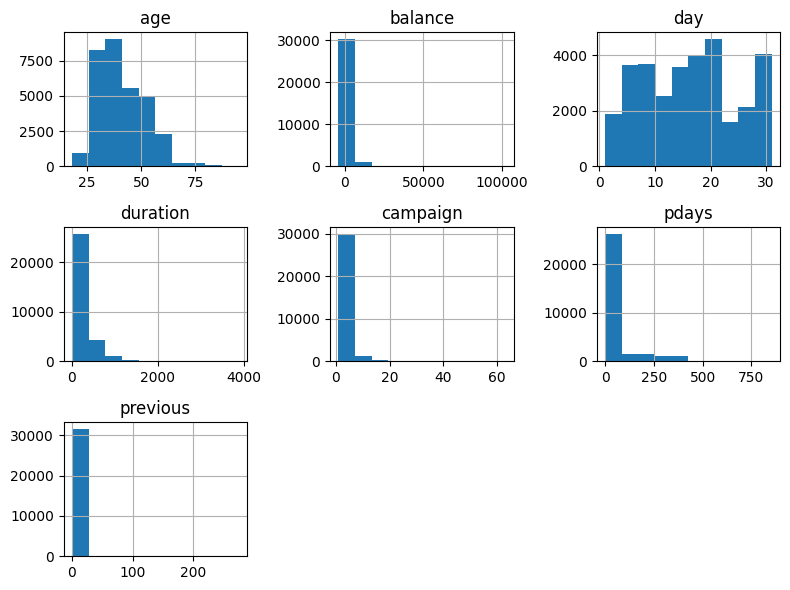

In [86]:
df_trn[num_cols].hist(figsize=(8,6))
plt.tight_layout()

* Binary Feature(이진분류 변수) 지정

In [87]:
yn_cols = [col for col in df_trn[cat_cols].columns if set(df_trn[col].unique()) <= {'yes', 'no'}]
not_yn_cols = [col for col in cat_cols if not set(df_trn[col].unique()) <= {'yes', 'no'}]

* Binary Feature 시각화

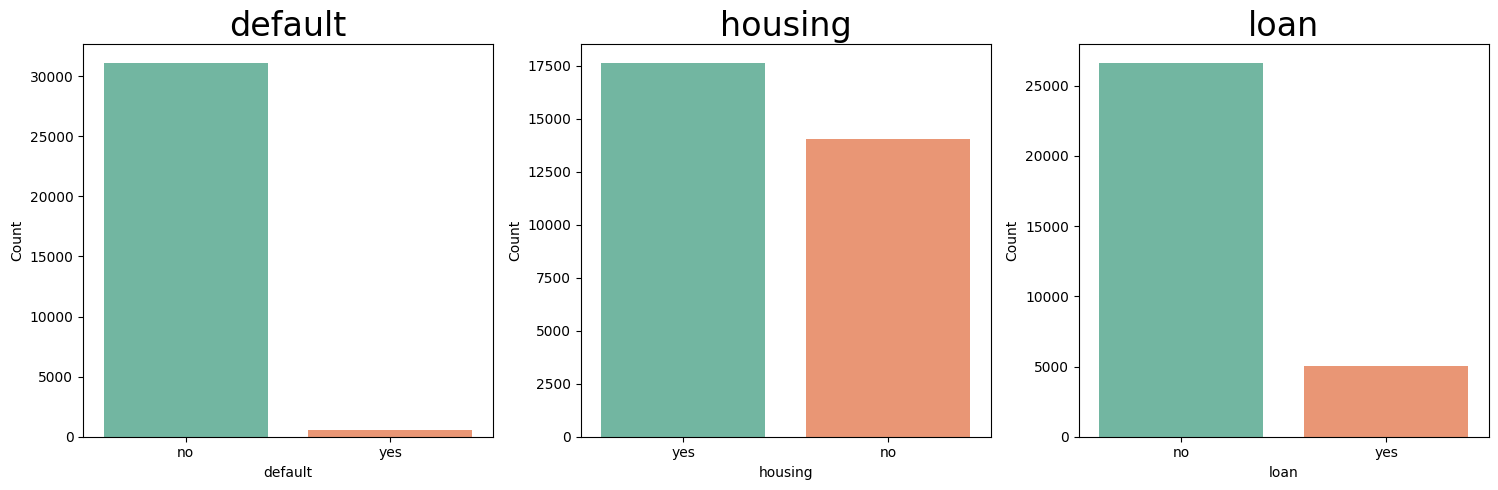

In [88]:
# 변수 개수와 행, 열의 수를 설정
n_cols = 7  # 한 행에 표시할 변수 개수 (여기서는 3개)
n_rows = (len(yn_cols) + n_cols - 1) // n_cols  # 필요한 행의 수 계산

# 전체 그림 크기 설정 (각 서브플롯의 크기를 고려해서 조정)
plt.figure(figsize=(n_cols * 5, n_rows * 5))

# 각 범주형 변수에 대해 countplot을 그립니다
for i, col in enumerate(yn_cols, 1):
    plt.subplot(n_rows, n_cols, i)  # 서브플롯 지정 (n_rows x n_cols)
    sns.countplot(x=col, data=df_trn, palette="Set2")
    plt.title(f'{col}', fontsize=24)
    plt.xlabel(col)
    plt.ylabel('Count')

# 레이아웃 조정
plt.tight_layout()
plt.show()

* Not Binary Feature 시각화

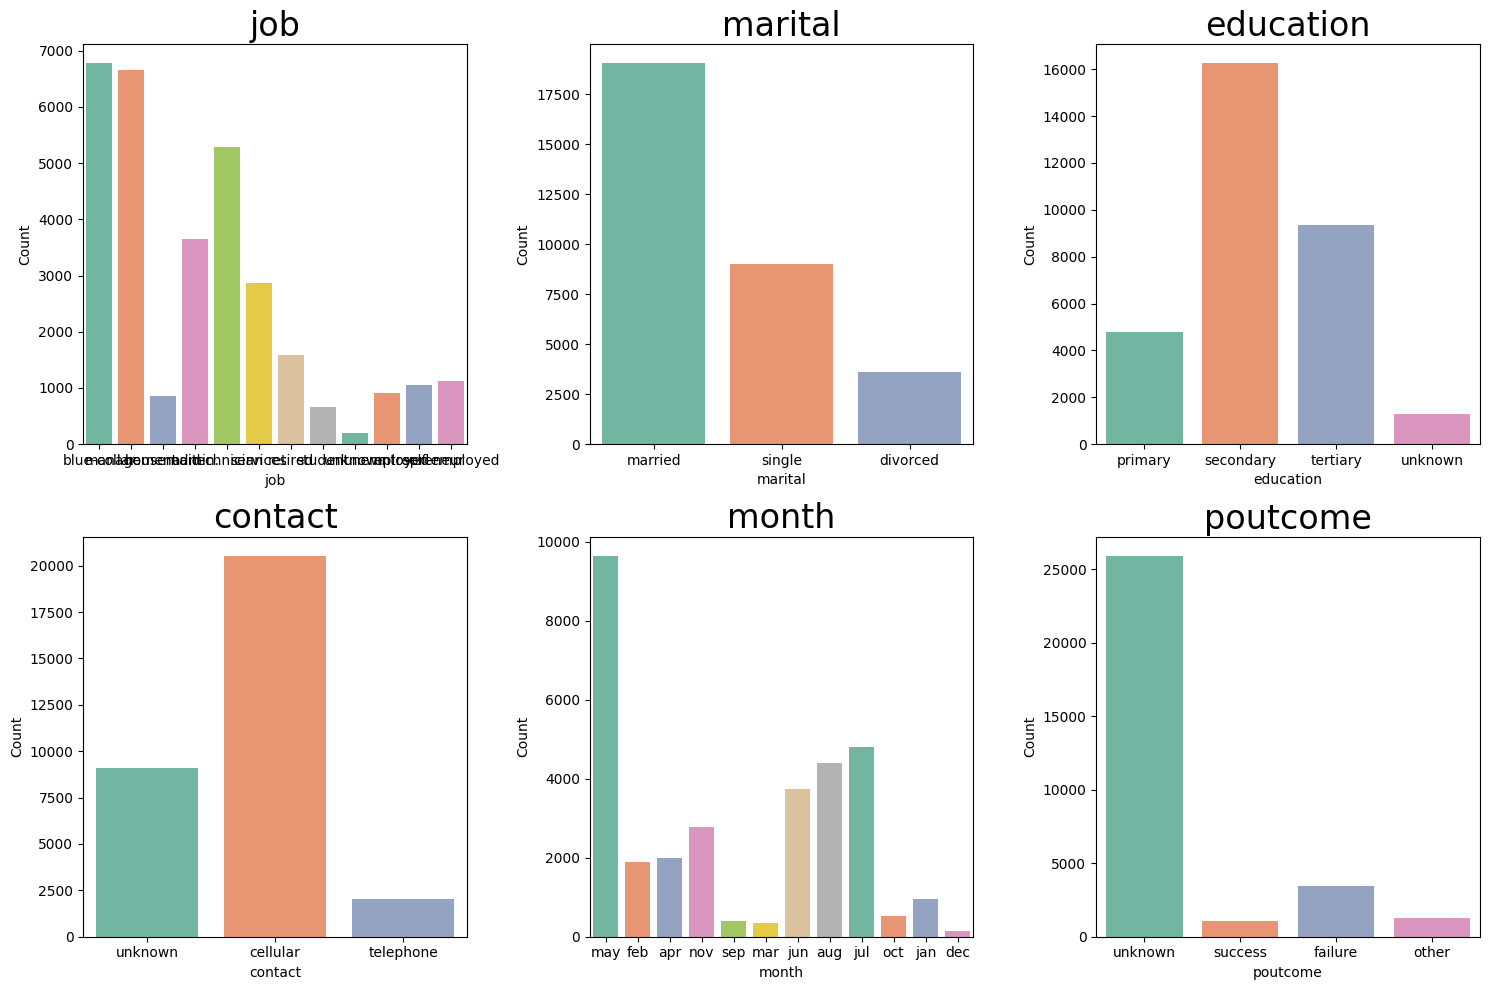

In [89]:
# 변수 개수와 행, 열의 수를 설정
n_cols = 3  # 한 행에 표시할 변수 개수 (여기서는 3개)
n_rows = (len(not_yn_cols) + n_cols - 1) // n_cols  # 필요한 행의 수 계산

# 전체 그림 크기 설정 (각 서브플롯의 크기를 고려해서 조정)
plt.figure(figsize=(n_cols * 5, n_rows * 5))

# 각 범주형 변수에 대해 countplot을 그립니다
for i, col in enumerate(not_yn_cols, 1):
    plt.subplot(n_rows, n_cols, i)  # 서브플롯 지정 (n_rows x n_cols)
    sns.countplot(x=col, data=df_trn, palette="Set2")
    plt.title(f'{col}', fontsize=24)
    plt.xlabel(col)
    plt.ylabel('Count')

# 레이아웃 조정
plt.tight_layout()
plt.show()

# PreProcessing

* Binary Feature Mapping

In [90]:
df_trn['default'] = df_trn['default'].apply(lambda x: 1 if x == 'yes' else 0)
df_trn['housing'] = df_trn['housing'].apply(lambda x: 1 if x == 'yes' else 0)
df_trn['loan'] = df_trn['loan'].apply(lambda x: 1 if x == 'yes' else 0)

df_tst['default'] = df_tst['default'].apply(lambda x: 1 if x == 'yes' else 0)
df_tst['housing'] = df_tst['housing'].apply(lambda x: 1 if x == 'yes' else 0)
df_tst['loan'] = df_tst['loan'].apply(lambda x: 1 if x == 'yes' else 0)

* Binary Feature Mapping

In [91]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

num_pipeline = Pipeline([
    ('scaliing', MinMaxScaler())
])

cat_pipeline = Pipeline([
    ('encoding1', OneHotEncoder(sparse_output=False,handle_unknown='ignore'))
])

In [92]:
col_transformer = ColumnTransformer(
    [
        ('num', num_pipeline, num_cols),
        ('yn', 'passthrough', yn_cols),
        ('not_yn', cat_pipeline, not_yn_cols),
        ('new', 'passthrough', new_cols),
    ], 
    remainder='drop', 
    verbose_feature_names_out=False, 
    # force_int_remainder_cols=False
)
col_transformer.set_output(transform='pandas')

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaliing', MinMaxScaler())]),
                                 ['age', 'balance', 'day', 'duration',
                                  'campaign', 'pdays', 'previous']),
                                ('yn', 'passthrough',
                                 ['default', 'housing', 'loan']),
                                ('not_yn',
                                 Pipeline(steps=[('encoding1',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['job', 'marital', 'education', 'contact',
                                  'month', 'poutcome']),
                                ('new', 'passthrough',
                                 ['contact_duration', 'poutcome_balance'])],
                  verbose_feature_names_out=False)

In [93]:
df_trn1 = col_transformer.fit_transform(df_trn)
df_tst1 = col_transformer.transform(df_tst)

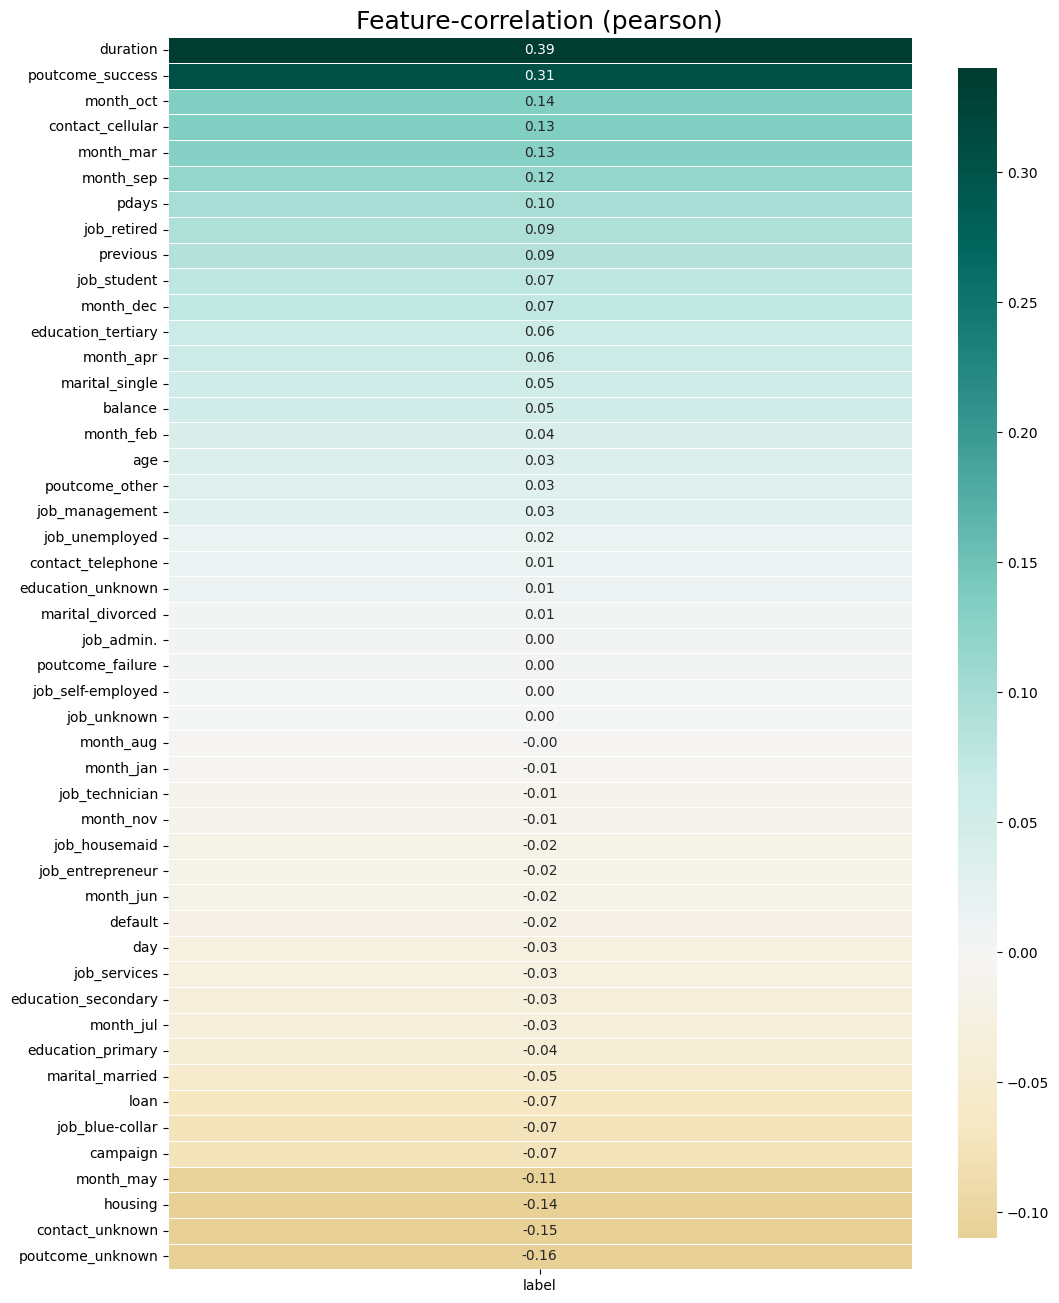

In [94]:
import klib

klib.corr_plot(data = df_trn1,
               target = df_trn['label'],
               figsize = (12, 16))

plt.show()

# Feature Selection

In [95]:
df_trn_preprocessed = pd.concat((df_trn1, df_trn['label']), axis=1)

In [96]:
X_train = df_trn_preprocessed.drop(columns=['label'])
y_train = df_trn['label']

* 수치형, 범주형 변수 재지정

In [97]:
cat_cols2 = df_trn_preprocessed.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols2 = [x for x in df_trn.columns if x not in y_cols+cat_cols]

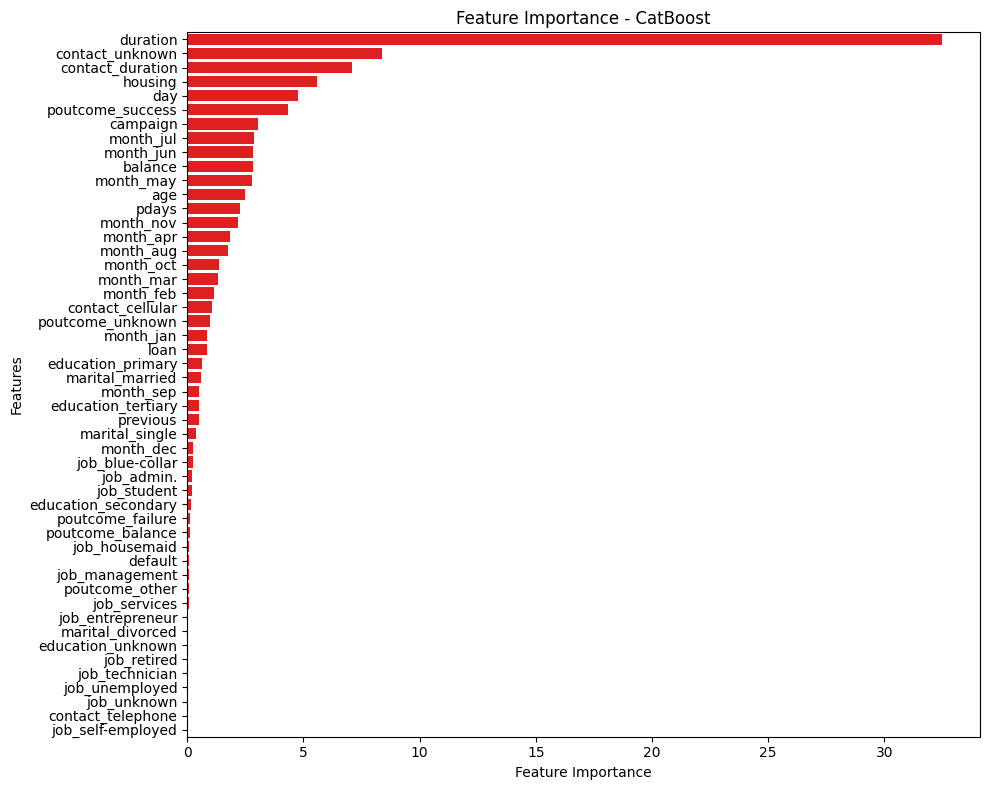

In [98]:
import catboost as cb
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# 예시 CatBoost 모델 학습
catboost_model = cb.CatBoostClassifier(iterations=100, depth=6, learning_rate=0.1, verbose=0)  # 하이퍼파라미터는 필요에 따라 조정
catboost_model.fit(X_train, y_train, cat_features=cat_cols2)  # X_train, y_train은 훈련 데이터

# CatBoost 피처 중요도 추출
catboost_feature_importance = catboost_model.get_feature_importance()

# 데이터프레임 생성 (CatBoost의 중요도)
feature_names = X_train.columns  # 피처 이름
catboost_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance_CatBoost': catboost_feature_importance
})
catboost_importance_df = catboost_importance_df.sort_values(by='Importance_CatBoost', ascending=False)

# CatBoost 중요도 시각화
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance_CatBoost', y='Feature', data=catboost_importance_df, color='red')
plt.title("Feature Importance - CatBoost")
plt.xlabel("Feature Importance")
plt.ylabel("Features")

# 레이아웃 조정 및 표시
plt.tight_layout()
plt.show()

job_admin. 변수 제거 필요성

# Modeling

In [100]:
X_train = df_trn_preprocessed.drop(columns=['label','job_admin.'])
y_train = df_trn['label']

X_test = df_tst1.drop(columns=['job_admin.'])

In [101]:
import optuna
from sklearn.model_selection import cross_val_score
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE



# 4. Optuna 최적화 함수 정의
def objective(trial):
    # 하이퍼파라미터 샘플링 (CatBoost 하이퍼파라미터)
    catboost_depth = trial.suggest_int('catboost_depth', 4, 10)
    catboost_learning_rate = trial.suggest_loguniform('catboost_learning_rate', 0.01, 0.1)
    catboost_iterations = trial.suggest_int('catboost_iterations', 100, 500)
    catboost_l2_leaf_reg = trial.suggest_loguniform('catboost_l2_leaf_reg', 1, 10)
    catboost_scale_pos_weight = trial.suggest_int('catboost_scale_pos_weight', 1, 5)

    # CatBoost 모델 생성
    catboost_model = CatBoostClassifier(
        depth=catboost_depth,
        learning_rate=catboost_learning_rate,
        iterations=catboost_iterations,
        l2_leaf_reg=catboost_l2_leaf_reg,
        scale_pos_weight=catboost_scale_pos_weight,
        random_state=42,
        cat_features=cat_cols2,  # 범주형 변수 지정
        verbose=0
    )

    # 교차 검증을 통한 F1 스코어 계산
    score = cross_val_score(catboost_model, X_train, y_train, cv=3, scoring='f1', n_jobs=-1).mean()
    
    return score

# 5. Optuna 스터디 생성 및 최적화 실행
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

# 6. 최적 파라미터 출력
print('Final Params:', study.best_params)

# 7. 최고의 성능 출력
print('Best Score:', study.best_value)

# 8. 테스트 데이터에 대한 예측 (최적 파라미터로 모델 재학습 후 예측)
best_params = study.best_params

# 최적의 CatBoost 모델 설정
best_catboost_model = CatBoostClassifier(
    depth=best_params['catboost_depth'],
    learning_rate=best_params['catboost_learning_rate'],
    iterations=best_params['catboost_iterations'],
    l2_leaf_reg=best_params['catboost_l2_leaf_reg'],
    scale_pos_weight=best_params['catboost_scale_pos_weight'],
    random_state=42,
    cat_features=cat_cols2,  # 범주형 변수 지정
    verbose=0
)

# 최적의 모델 학습
best_catboost_model.fit(X_train, y_train)

# 예측
y_pred = best_catboost_model.predict(X_test)

[I 2024-12-04 16:49:55,190] A new study created in memory with name: no-name-f42ac732-4147-4411-b57f-39c6c9d6340e
[I 2024-12-04 16:50:41,190] Trial 0 finished with value: 0.576832381254553 and parameters: {'catboost_depth': 10, 'catboost_learning_rate': 0.010136947249413285, 'catboost_iterations': 246, 'catboost_l2_leaf_reg': 5.725880102777349, 'catboost_scale_pos_weight': 2}. Best is trial 0 with value: 0.576832381254553.
[I 2024-12-04 16:51:25,476] Trial 1 finished with value: 0.616644273416432 and parameters: {'catboost_depth': 9, 'catboost_learning_rate': 0.0202443308348367, 'catboost_iterations': 354, 'catboost_l2_leaf_reg': 1.9322806185061445, 'catboost_scale_pos_weight': 4}. Best is trial 1 with value: 0.616644273416432.
[I 2024-12-04 16:52:52,193] Trial 2 finished with value: 0.6134941469749464 and parameters: {'catboost_depth': 10, 'catboost_learning_rate': 0.011210965111185786, 'catboost_iterations': 471, 'catboost_l2_leaf_reg': 1.9616281121882777, 'catboost_scale_pos_weight'

Final Params: {'catboost_depth': 5, 'catboost_learning_rate': 0.08325074142014648, 'catboost_iterations': 465, 'catboost_l2_leaf_reg': 2.6780261467605637, 'catboost_scale_pos_weight': 3}
Best Score: 0.630052121599551


# 임계값 조정

* Cross-Validation을 활용해 Optimal Threshold 구하기

Optimal Threshold: 0.48


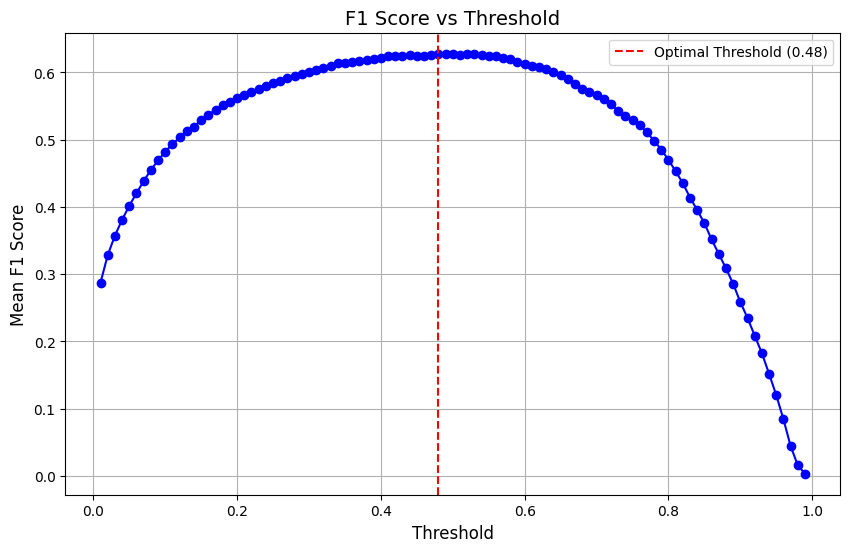

In [102]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# 교차 검증을 위한 KFold 생성
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 최적 임계값을 찾기 위한 리스트
best_thresholds = []
thresholds = [i * 0.01 for i in range(1, 100)]  # 임계값 후보 (0.01부터 0.99까지)

# F1 점수를 저장할 리스트
f1_scores_per_threshold = {threshold: [] for threshold in thresholds}

# 교차 검증을 통해 최적 임계값을 찾음
for train_idx, val_idx in cv.split(X_train, y_train):  # 원본 데이터 사용
    # iloc을 사용하여 인덱스 기반으로 데이터를 선택
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # 모델 학습
    best_catboost_model.fit(X_train_fold, y_train_fold)
    
    # 예측 확률 출력
    y_pred_prob = best_catboost_model.predict_proba(X_val_fold)[:, 1]  # 양성 클래스 확률

    # 다양한 임계값에서 평가
    for threshold in thresholds:
        y_pred_bin = (y_pred_prob >= threshold).astype(int)  # 임계값 기준 이진 분류
        f1 = f1_score(y_val_fold, y_pred_bin)  # F1 스코어 계산
        f1_scores_per_threshold[threshold].append(f1)

# 평균 F1 점수 계산
mean_f1_scores = {threshold: np.mean(f1_scores_per_threshold[threshold]) for threshold in thresholds}

# 최적 임계값 찾기 (평균 F1 점수가 최대인 임계값)
optimal_threshold = max(mean_f1_scores, key=mean_f1_scores.get)
print(f'Optimal Threshold: {optimal_threshold}')

# F1 점수의 변화를 시각화
plt.figure(figsize=(10, 6))
plt.plot(thresholds, [mean_f1_scores[threshold] for threshold in thresholds], marker='o', linestyle='-', color='b')
plt.title('F1 Score vs Threshold', fontsize=14)
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Mean F1 Score', fontsize=12)
plt.grid(True)
plt.axvline(x=optimal_threshold, color='r', linestyle='--', label=f'Optimal Threshold ({optimal_threshold:.2f})')
plt.legend()
plt.show()

* Positive Class 분포 확인

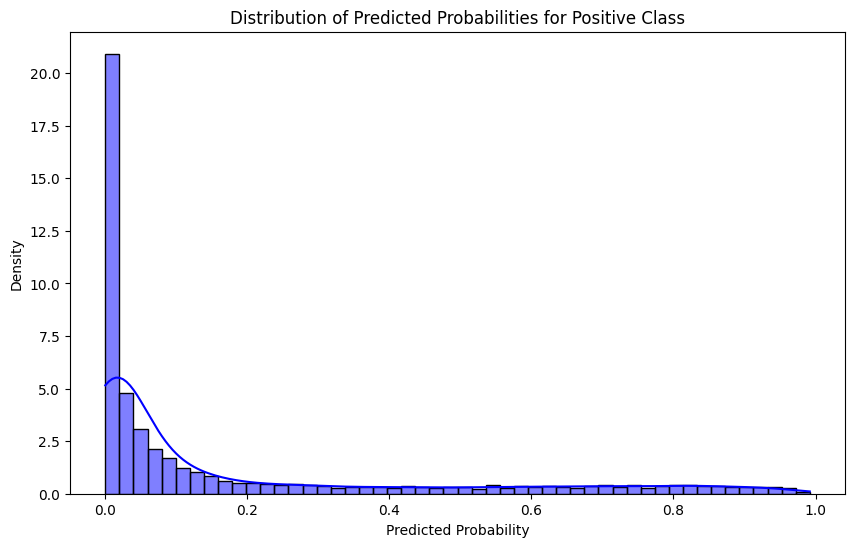

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

# 테스트 데이터에 대해 예측 확률 계산
pred_probs = best_catboost_model.predict_proba(X_test)

# 예측 확률에서 양성 클래스(1)에 대한 확률 추출
positive_class_probs = pred_probs[:, 1]

# 히스토그램으로 예측 확률 시각화
plt.figure(figsize=(10, 6))
sns.histplot(positive_class_probs, bins=50, kde=True, color='blue', stat='density')

# 그래프 꾸미기
plt.title('Distribution of Predicted Probabilities for Positive Class')
plt.xlabel('Predicted Probability')
plt.ylabel('Density')
plt.show()

* Optimal Threshold 적용

In [104]:
from sklearn.metrics import f1_score
import numpy as np

# 임계값을 적용하는 함수
def apply_threshold(pred_probs, threshold):
    return (pred_probs[:, 1] >= threshold).astype(int)

# 임계값 조정 
threshold = 0.48
y_pred_thr = apply_threshold(pred_probs, threshold)

# 제출

In [105]:
df_submission = pd.read_csv('submission_example.csv')

In [106]:
df_submission.head()

,ID,label
0,test00001,0
1,test00002,0
2,test00003,0
3,test00004,0
4,test00005,0


In [107]:
df_submission['label'] = y_pred_thr

In [108]:
df_submission['label'].value_counts()

label
0    11620
1     1944
Name: count, dtype: int64

In [109]:
# 새로운 파일로 저장하기
filename = 'catb.csv'
df_submission.to_csv(filename, index=False)

-----------------------

# **Submission Ensemble**

-------------------

* 가중치 설정하여 Submission Ensemble
-- (CatB : LGBM : XGB = 2 : 1 : 1)

In [123]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings("ignore")

# submissions 폴더가 존재하는지 확인
folder = 'esb'
if not os.path.exists(folder):
    raise Exception(f"폴더 '{folder}'가 존재하지 않습니다.")

# 초기화
nf = 0
slist = None
weights = []  # 모델별 가중치를 저장할 리스트

# 파일 읽기 및 병합
for f in os.listdir(folder):
    ext = os.path.splitext(f)[-1]
    if ext == '.csv': 
        # 파일 읽기
        s = pd.read_csv(os.path.join(folder, f))
        
        # 'ID' 및 'label' 열 확인
        if 'ID' not in s.columns or 'label' not in s.columns:
            raise Exception(f"파일 '{f}'에 'ID' 또는 'label' 열이 없습니다.")
        
        # 병합 시 접미사 추가
        if nf == 0:
            slist = s
        else:
            # 병합 시 'label' 열에 접미사 추가하여 구분
            slist = pd.merge(slist, s, on="ID", how='inner', suffixes=(f'_model{nf-1}', f'_model{nf}'))
        
        # 모델별 가중치 설정
        if nf == 0:
            weights.append(2)  # 첫 번째 모델에 2 가중치
        elif nf == 1:
            weights.append(1)  # 두 번째 모델에 1 가중치
        elif nf == 2:
            weights.append(1)  # 세 번째 모델에 1 가중치
        else:
            weights.append(1)  # 추가적인 모델에 기본 1 가중치
        
        nf += 1

# 앙상블 계산
if nf < 2:
    raise Exception("앙상블을 위해 최소 두 개의 CSV 파일이 필요합니다.")

# 예측값 계산 (각 모델의 'label' 열에 가중치를 곱해 결합)
pred = np.zeros(len(slist))
weight_sum = sum(weights)  # 가중치의 합

# 'label_model0', 'label_model1' 등의 열을 동적으로 참조하여 계산
for col in slist.columns:
    if col.startswith('label_model'):  # 'label_model0', 'label_model1' 등으로 시작하는 열만 처리
        # 'label_model0' -> 0, 'label_model1' -> 1, 등으로 숫자만 추출하기
        model_idx = int(col.split('_')[-1].replace('model', ''))  # 'model0' -> 0, 'model1' -> 1로 변경
        pred += slist[col] * weights[model_idx]  # 가중치를 곱한 예측값을 더함

pred /= weight_sum  # 가중치의 합으로 나누어 최종 예측값 계산

# 최종 결과 저장
t = pd.Timestamp.now()
fname = f"weighted_mean_submission_(2)(1)(1).csv"
pd.DataFrame({'ID': slist['ID'], 'label': pred}).to_csv(fname, index=False)
print(f"'{fname}' is ready to submit.")


'weighted_mean_submission_(2)(1)(1).csv' is ready to submit.


In [124]:
import pandas as pd

# 앙상블 결과 불러오기
ensemble_result = pd.read_csv('weighted_mean_submission_(2)(1)(1).csv')

# 임계값 설정 및 이진화
threshold = 0.5
ensemble_result['label'] = (ensemble_result['label'] >= threshold).astype(int)

# 결과 저장
ensemble_result.to_csv('submission_(2)(1)(1)_0.5.csv', index=False)

# ***이상입니다. 감사합니다!!***